# MATH4010 Final Project — Problem 1
## Geometry and Monte Carlo Volume Estimation

We study two families of $n$-dimensional balls:

$$A_n = \left\{x \in \mathbb{R}^n : \left\|x - \tfrac{1}{2}\mathbf{1}\right\|_2 \leq \tfrac{1}{2}\right\} \quad\text{(ball of radius }\tfrac{1}{2}\text{ inscribed in }[0,1]^n)$$

$$B_n = \left\{x \in \mathbb{R}^n : \|x\|_2 \leq 1\right\} \quad\text{(unit ball at the origin)}$$

**Exact volume formula for an $n$-ball of radius $r$:**
$$V_n(r) = \frac{\pi^{n/2}}{\Gamma(n/2+1)}\,r^n$$

So:
$$\operatorname{Vol}(B_n) = \frac{\pi^{n/2}}{\Gamma(n/2+1)}, \qquad \operatorname{Vol}(A_n) = \frac{1}{2^n}\operatorname{Vol}(B_n)$$

In [43]:
import math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import gammaln
from scipy.integrate import quad
from scipy.stats import qmc

warnings.filterwarnings("ignore")
SEED = 4010
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "font.size": 11})
print("Setup complete. SEED =", SEED)

Setup complete. SEED = 4010


---
## Core library

All functions are defined once here. Every experiment below just calls them — no duplicated code.

In [44]:
# ── Exact volumes (log-scale to handle n=100 without underflow) ───────────────

def log_vol_B(n: int) -> float:
    """log Vol(B_n) = (n/2) log π − log Γ(n/2 + 1)"""
    return (n / 2) * math.log(math.pi) - gammaln(n / 2 + 1)

def log_vol_A(n: int) -> float:
    """log Vol(A_n) = log Vol(B_n) − n log 2"""
    return log_vol_B(n) - n * math.log(2)

def exact_vol(shape: str, n: int) -> float:
    """Exact volume; returns 0.0 for extreme underflow."""
    lv = log_vol_A(n) if shape == "A" else log_vol_B(n)
    return math.exp(lv) if lv > -745 else 0.0


# ── Membership tests ─────────────────────────────────────────────────────────

def in_A(x: np.ndarray) -> np.ndarray:
    """Boolean mask: is each row of x inside A_n?"""
    return np.sum((x - 0.5) ** 2, axis=1) <= 0.25

def in_B(x: np.ndarray) -> np.ndarray:
    """Boolean mask: is each row of x inside B_n?"""
    return np.sum(x ** 2, axis=1) <= 1.0


# ── Bounding-box Monte Carlo ──────────────────────────────────────────────────

def monte_carlo(shape: str, n: int, N: int = 100_000,
                seed: int = SEED, chunk: int = 50_000) -> dict:
    """
    Bounding-box hit-or-miss Monte Carlo.

    A_n: sample from [0,1]^n,  box_vol = 1.
    B_n: sample from [−1,1]^n, box_vol = 2^n.

    Returns a dict with shape, n, N, hits, hit_rate, estimate,
    exact, abs_error, rel_error, runtime.
    """
    rng = np.random.default_rng(seed)
    hits, done = 0, 0
    t0 = time.perf_counter()

    while done < N:
        m = min(chunk, N - done)
        if shape == "A":
            x = rng.uniform(0, 1, (m, n))
            hits += int(in_A(x).sum())
            log_box = 0.0
        else:
            x = rng.uniform(-1, 1, (m, n))
            hits += int(in_B(x).sum())
            log_box = n * math.log(2)
        done += m

    runtime = time.perf_counter() - t0
    hit_rate = hits / N
    log_est  = (log_box + math.log(hit_rate)) if hit_rate > 0 else -math.inf
    estimate = math.exp(log_est) if log_est > -745 else 0.0
    exact    = exact_vol(shape, n)

    return dict(
        shape=shape, n=n, N=N,
        hits=hits, hit_rate=hit_rate,
        estimate=estimate, exact=exact,
        abs_error=abs(estimate - exact),
        rel_error=(abs(estimate - exact) / exact) if exact > 0 else float("nan"),
        runtime=runtime,
    )


# ── Repeated Monte Carlo ──────────────────────────────────────────────────────

def repeated_mc(shape: str, n: int, N: int = 10_000,
                repeats: int = 30, seed: int = SEED) -> dict:
    """
    Run monte_carlo `repeats` times and summarise variability.
    Returns mean, std, 95% CI half-width, zero-hit fraction.
    """
    estimates = [monte_carlo(shape, n, N, seed=seed + k)["estimate"]
                 for k in range(repeats)]
    arr = np.array(estimates)
    return dict(
        shape=shape, n=n, N=N, repeats=repeats,
        mean=arr.mean(), std=arr.std(ddof=1),
        ci95=1.96 * arr.std(ddof=1) / math.sqrt(repeats),
        zero_hit_frac=(arr == 0).mean(),
    )


# ── Sobol quasi-Monte Carlo ───────────────────────────────────────────────────

def quasi_mc(shape: str, n: int, m: int = 13, seed: int = SEED) -> dict:
    """
    Sobol sequence quasi-Monte Carlo (N = 2^m points).
    Same bounding-box logic as monte_carlo.
    """
    N = 2 ** m
    sampler = qmc.Sobol(d=n, scramble=True, seed=seed)
    u = sampler.random_base2(m=m)          # uniform on [0,1]^n

    if shape == "A":
        mask = in_A(u)
        estimate = mask.mean()
    else:
        x = 2 * u - 1
        mask = in_B(x)
        estimate = (2 ** n) * mask.mean()

    exact = exact_vol(shape, n)
    return dict(
        shape=shape, n=n, N=N,
        hits=int(mask.sum()), estimate=estimate, exact=exact,
        abs_error=abs(estimate - exact),
        rel_error=(abs(estimate - exact) / exact) if exact > 0 else float("nan"),
    )


# ── Convenience: run across many N values ─────────────────────────────────────

def sweep_N(shape: str, n: int,
            N_list=(100, 1_000, 10_000, 100_000),
            seed: int = SEED) -> pd.DataFrame:
    """Run monte_carlo for every N in N_list and return a tidy DataFrame."""
    return pd.DataFrame([monte_carlo(shape, n, N, seed=seed + N) for N in N_list])


# ── Convenience: compute exact table across dimensions ────────────────────────

def exact_table(dims=(1,2,3,5,10,20,50,100)) -> pd.DataFrame:
    """Return log/exact volumes of A_n and B_n for each dimension."""
    rows = []
    for n in dims:
        lA, lB = log_vol_A(n), log_vol_B(n)
        rows.append(dict(
            n=n,
            log_vol_A=lA, log_vol_B=lB,
            vol_A=math.exp(lA) if lA > -745 else 0.0,
            vol_B=math.exp(lB) if lB > -745 else 0.0,
            log_hit_rate_A=lA,                  # box for A is [0,1]^n, vol=1
            log_hit_rate_B=lB - n*math.log(2),  # box for B is [-1,1]^n, vol=2^n
        ))
    return pd.DataFrame(rows)


print("Core library ready.")
print("Quick sanity check:")
print(f"  Vol(A2) = {exact_vol('A',2):.6f}  (expected π/4  ≈ {math.pi/4:.6f})")
print(f"  Vol(B2) = {exact_vol('B',2):.6f}  (expected π    ≈ {math.pi:.6f})")
print(f"  Vol(A3) = {exact_vol('A',3):.6f}  (expected π/6  ≈ {math.pi/6:.6f})")
print(f"  Vol(B3) = {exact_vol('B',3):.6f}  (expected 4π/3 ≈ {4*math.pi/3:.6f})")

Core library ready.
Quick sanity check:
  Vol(A2) = 0.785398  (expected π/4  ≈ 0.785398)
  Vol(B2) = 3.141593  (expected π    ≈ 3.141593)
  Vol(A3) = 0.523599  (expected π/6  ≈ 0.523599)
  Vol(B3) = 4.188790  (expected 4π/3 ≈ 4.188790)


---
## Part 1.a — $A_2$ and $B_2$ (2-D)

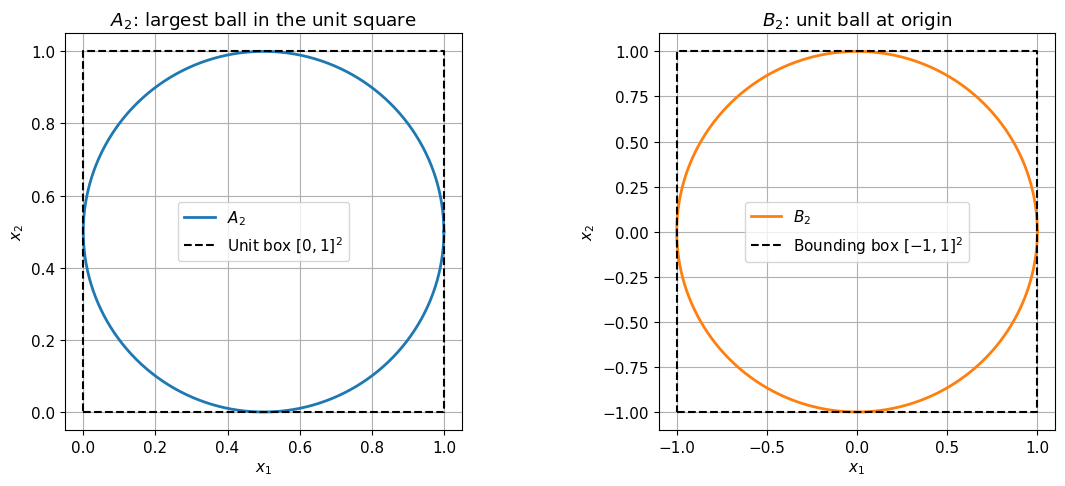

Exact area  A2 = π/4  = 0.785398
Exact area  B2 = π    = 3.141593


In [45]:
# ── Visualise ──────────────────────────────────────────────────────────────────
theta = np.linspace(0, 2*np.pi, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(0.5 + 0.5*np.cos(theta), 0.5 + 0.5*np.sin(theta), lw=2, label="$A_2$")
ax.plot([0,1,1,0,0], [0,0,1,1,0], "k--", label="Unit box $[0,1]^2$")
ax.set(title="$A_2$: largest ball in the unit square",
       xlabel="$x_1$", ylabel="$x_2$", aspect="equal")
ax.legend()

ax = axes[1]
ax.plot(np.cos(theta), np.sin(theta), lw=2, color="C1", label="$B_2$")
ax.plot([-1,1,1,-1,-1], [-1,-1,1,1,-1], "k--", label="Bounding box $[-1,1]^2$")
ax.set(title="$B_2$: unit ball at origin",
       xlabel="$x_1$", ylabel="$x_2$", aspect="equal")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Exact area  A2 = π/4  = {exact_vol('A',2):.6f}")
print(f"Exact area  B2 = π    = {exact_vol('B',2):.6f}")

In [46]:
# ── Monte Carlo convergence across N ──────────────────────────────────────────
df_A2 = sweep_N("A", n=2)
df_B2 = sweep_N("B", n=2)

cols = ["shape","n","N","exact","estimate","abs_error","rel_error","hit_rate","runtime"]
pd.concat([df_A2, df_B2])[cols].round(6)

,shape,n,N,exact,estimate,abs_error,rel_error,hit_rate,runtime
0,A,2,100,0.785398,0.81000,0.024602,0.031324,0.81000,0.000227
1,A,2,1000,0.785398,0.78700,0.001602,0.002040,0.78700,0.000154
2,A,2,10000,0.785398,0.78920,0.003802,0.004841,0.78920,0.000483
3,A,2,100000,0.785398,0.78626,0.000862,0.001097,0.78626,0.004591
0,B,2,100,3.141593,3.24000,0.098407,0.031324,0.81000,0.000190
1,B,2,1000,3.141593,3.14800,0.006407,0.002040,0.78700,0.000215
2,B,2,10000,3.141593,3.15680,0.015207,0.004841,0.78920,0.000509
3,B,2,100000,3.141593,3.14504,0.003447,0.001097,0.78626,0.004353


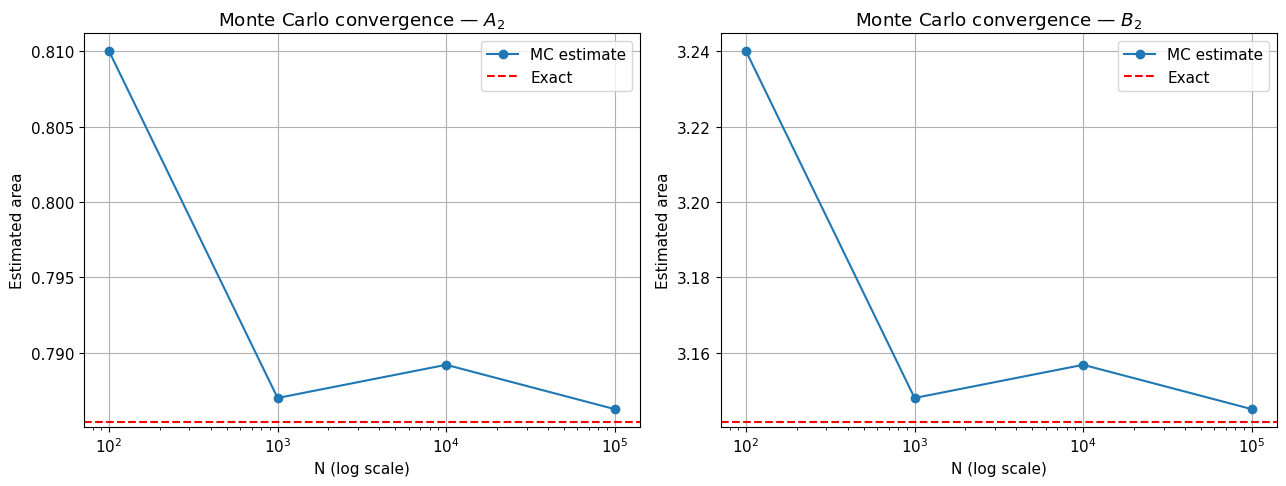

In [47]:
# ── Convergence plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, label in zip(axes, [df_A2, df_B2], ["$A_2$","$B_2$"]):
    ax.plot(df["N"], df["estimate"], "o-", label="MC estimate")
    ax.axhline(df["exact"].iloc[0], ls="--", color="red", label="Exact")
    ax.set(xscale="log", title=f"Monte Carlo convergence — {label}",
           xlabel="N (log scale)", ylabel="Estimated area")
    ax.legend()

plt.tight_layout()
plt.show()

### 1.a.0 Bounding Box Effect in One Dimension

Before comparing the two-dimensional balls, the same issue is visible in the simplest case. For $A_1=[0,1]$, the minimal bounding box is exactly $[0,1]$, so every sample is useful. A bad bounding box still gives an unbiased estimate, but the lower hit rate makes the running estimate much noisier.


In [ ]:
# ============================================================
# Effect of bounding box size on Monte Carlo estimation
# Example: estimate length of A_1 using minimal and bad boxes
# ============================================================


def mc_running_estimate_A1_box(N=100000, low=0.0, high=1.0, seed=42):
    """
    Estimate length of A_1 = [0, 1] using bounding box [low, high].
    Returns running estimates.
    """
    rng = np.random.default_rng(seed)

    x = rng.uniform(low, high, size=N)
    inside = (x >= 0.0) & (x <= 1.0)

    box_length = high - low
    cumulative_hits = np.cumsum(inside)
    iterations = np.arange(1, N + 1)

    running_estimate = box_length * cumulative_hits / iterations

    return iterations, running_estimate, inside


N = 100000
true_length_A1 = 1.0

box_settings_A1 = [
    ("Minimal Bounding", 0.0, 1.0),
    ("Bad Bounding", -1.0, 2.0),
]

plt.figure(figsize=(8, 5))

summary_rows_A1 = []

for label, low, high in box_settings_A1:
    iterations, running_estimate, inside = mc_running_estimate_A1_box(
        N=N,
        low=low,
        high=high,
        seed=42
    )

    plt.plot(iterations, running_estimate, label=label)

    final_estimate = running_estimate[-1]
    abs_error = abs(final_estimate - true_length_A1)
    rel_error = abs_error / true_length_A1
    hit_rate = np.mean(inside)

    summary_rows_A1.append({
        "box": label,
        "interval": f"[{low}, {high}]",
        "box_length": high - low,
        "hit_rate": hit_rate,
        "final_estimate": final_estimate,
        "absolute_error": abs_error,
        "relative_error": rel_error
    })

plt.axhline(true_length_A1, linestyle="--", color="red", label="True value: 1")
plt.title("Impact of Bounding Box on $A_1$")
plt.xlabel("Iterations")
plt.ylabel("Estimation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

box_effect_summary_A1 = pd.DataFrame(summary_rows_A1)
display(box_effect_summary_A1)


### 1.a.1 Minimal versus Bad Bounding Boxes in Two Dimensions

The same effect appears for $A_2$ and $B_2$. The estimator is still unbiased when the bounding box is larger than necessary, but a larger box lowers the hit rate and increases the visible Monte Carlo noise.


In [ ]:
# ============================================================
# Effect of bounding box size on Monte Carlo estimation
# Example: estimate area of B_2 using different bounding boxes
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math


def mc_running_estimate_B2_box(N=100000, R=1.0, seed=42):
    """
    Estimate area of B_2 using bounding box [-R, R]^2.
    Returns running estimates.
    """
    rng = np.random.default_rng(seed)

    x = rng.uniform(-R, R, size=(N, 2))
    inside = np.sum(x ** 2, axis=1) <= 1.0

    box_area = (2 * R) ** 2

    cumulative_hits = np.cumsum(inside)
    iterations = np.arange(1, N + 1)

    running_estimate = box_area * cumulative_hits / iterations

    return iterations, running_estimate, inside


N = 100000
true_area_B2 = math.pi

box_settings = [
    ("Minimal box [-1,1]^2", 1.0),
    ("Bad box [-2,2]^2", 2.0),
    ("Very bad box [-5,5]^2", 5.0),
]

plt.figure(figsize=(8, 5))

summary_rows = []

for label, R in box_settings:
    iterations, running_estimate, inside = mc_running_estimate_B2_box(
        N=N,
        R=R,
        seed=42
    )

    plt.plot(iterations, running_estimate, label=label)

    final_estimate = running_estimate[-1]
    abs_error = abs(final_estimate - true_area_B2)
    rel_error = abs_error / true_area_B2
    hit_rate = np.mean(inside)

    summary_rows.append({
        "box": label,
        "R": R,
        "box_area": (2 * R) ** 2,
        "hit_rate": hit_rate,
        "final_estimate": final_estimate,
        "absolute_error": abs_error,
        "relative_error": rel_error
    })

plt.axhline(true_area_B2, linestyle="--", color="red", label="True area = pi")
plt.title("Effect of Bounding Box Size on Monte Carlo Estimation of $B_2$")
plt.xlabel("Iterations")
plt.ylabel("Area estimate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

box_effect_summary = pd.DataFrame(summary_rows)
display(box_effect_summary)


In [ ]:
# ============================================================
# Effect of bounding box size on Monte Carlo estimation
# Example: estimate area of A_2 using different bounding boxes
# ============================================================


def mc_running_estimate_A2_box(N=100000, low=0.0, high=1.0, seed=42):
    """
    Estimate area of A_2 using bounding box [low, high]^2.
    A_2 center is (0.5, 0.5), radius 0.5.
    """
    rng = np.random.default_rng(seed)

    x = rng.uniform(low, high, size=(N, 2))
    inside = np.sum((x - 0.5) ** 2, axis=1) <= 0.5 ** 2

    box_area = (high - low) ** 2

    cumulative_hits = np.cumsum(inside)
    iterations = np.arange(1, N + 1)

    running_estimate = box_area * cumulative_hits / iterations

    return iterations, running_estimate, inside


N = 100000
true_area_A2 = math.pi / 4

box_settings_A = [
    ("Minimal box [0,1]^2", 0.0, 1.0),
    ("Bad box [-1,2]^2", -1.0, 2.0),
    ("Very bad box [-5,5]^2", -5.0, 5.0),
]

plt.figure(figsize=(8, 5))

summary_rows_A = []

for label, low, high in box_settings_A:
    iterations, running_estimate, inside = mc_running_estimate_A2_box(
        N=N,
        low=low,
        high=high,
        seed=42
    )

    plt.plot(iterations, running_estimate, label=label)

    final_estimate = running_estimate[-1]
    abs_error = abs(final_estimate - true_area_A2)
    rel_error = abs_error / true_area_A2
    hit_rate = np.mean(inside)

    summary_rows_A.append({
        "box": label,
        "box_area": (high - low) ** 2,
        "hit_rate": hit_rate,
        "final_estimate": final_estimate,
        "absolute_error": abs_error,
        "relative_error": rel_error
    })

plt.axhline(true_area_A2, linestyle="--", color="red", label="True area = pi/4")
plt.title("Effect of Bounding Box Size on Monte Carlo Estimation of $A_2$")
plt.xlabel("Iterations")
plt.ylabel("Area estimate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

box_effect_summary_A = pd.DataFrame(summary_rows_A)
display(box_effect_summary_A)


---
## Part 1.b — $A_3$ and $B_3$ (3-D)

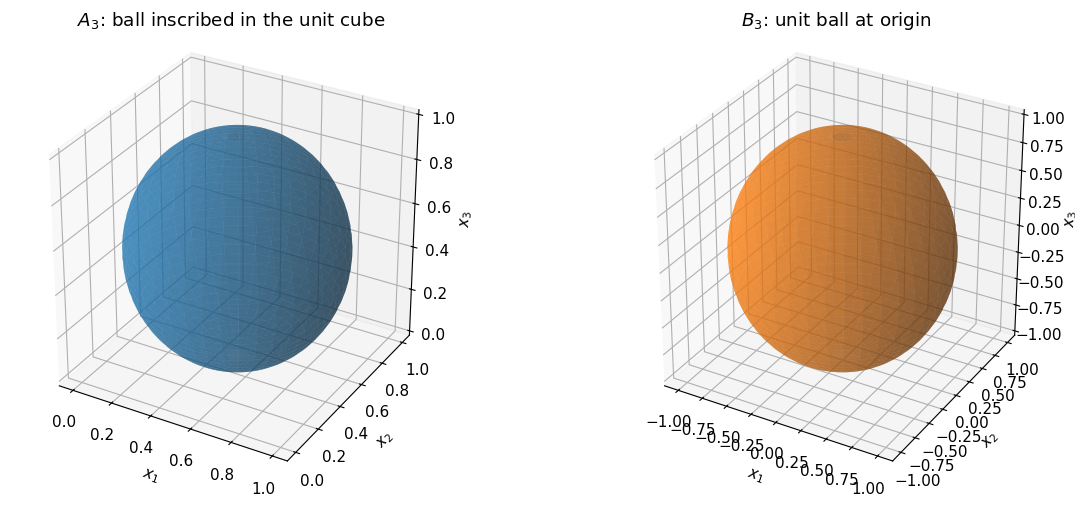

Exact volume A3 = π/6   = 0.523599
Exact volume B3 = 4π/3  = 4.188790


In [48]:
# ── Visualise ──────────────────────────────────────────────────────────────────
u = np.linspace(0, 2*np.pi, 80)
v = np.linspace(0,   np.pi, 40)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))

fig = plt.figure(figsize=(13, 5))

ax = fig.add_subplot(121, projection="3d")
ax.plot_surface(0.5+0.5*xs, 0.5+0.5*ys, 0.5+0.5*zs, alpha=0.55, color="C0")
ax.set(title="$A_3$: ball inscribed in the unit cube",
       xlabel="$x_1$", ylabel="$x_2$", zlabel="$x_3$")
ax.set_box_aspect([1,1,1])

ax = fig.add_subplot(122, projection="3d")
ax.plot_surface(xs, ys, zs, alpha=0.55, color="C1")
ax.set(title="$B_3$: unit ball at origin",
       xlabel="$x_1$", ylabel="$x_2$", zlabel="$x_3$")
ax.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()

print(f"Exact volume A3 = π/6   = {exact_vol('A',3):.6f}")
print(f"Exact volume B3 = 4π/3  = {exact_vol('B',3):.6f}")

In [49]:
# ── Monte Carlo — same sweep_N call, just change n ───────────────────────────
df_A3 = sweep_N("A", n=3)
df_B3 = sweep_N("B", n=3)

pd.concat([df_A3, df_B3])[cols].round(6)

,shape,n,N,exact,estimate,abs_error,rel_error,hit_rate,runtime
0,A,3,100,0.523599,0.51000,0.013599,0.025972,0.51000,0.000136
1,A,3,1000,0.523599,0.52600,0.002401,0.004586,0.52600,0.000136
2,A,3,10000,0.523599,0.52620,0.002601,0.004968,0.52620,0.000848
3,A,3,100000,0.523599,0.52539,0.001791,0.003421,0.52539,0.005819
0,B,3,100,4.188790,4.08000,0.108790,0.025972,0.51000,0.000061
1,B,3,1000,4.188790,4.20800,0.019210,0.004586,0.52600,0.000058
2,B,3,10000,4.188790,4.20960,0.020810,0.004968,0.52620,0.000340
3,B,3,100000,4.188790,4.20312,0.014330,0.003421,0.52539,0.005301


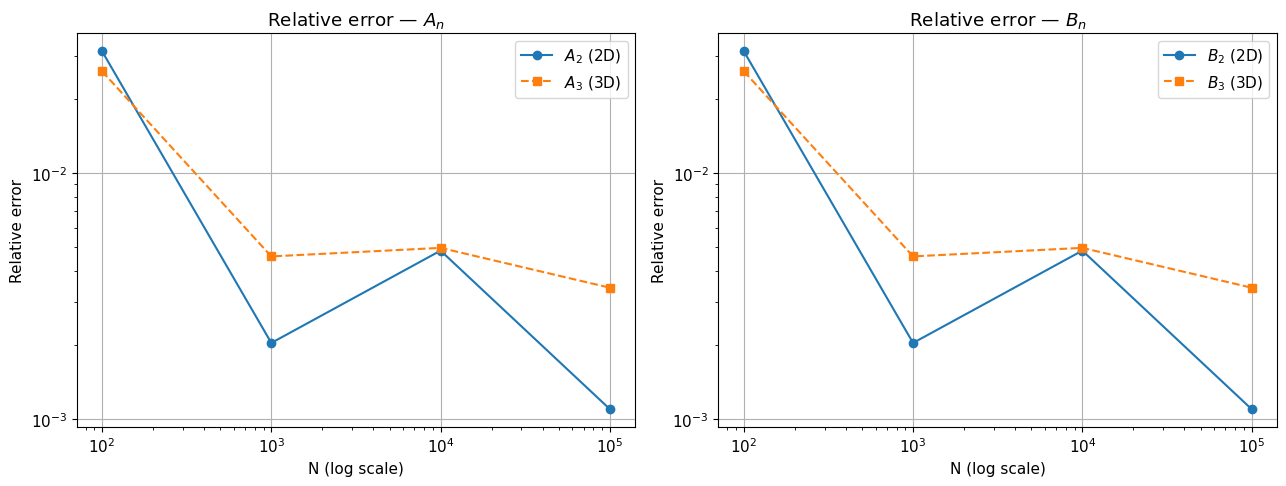

In [50]:
# ── Side-by-side comparison 2D vs 3D ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df2, df3, label in zip(axes, [df_A2, df_B2], [df_A3, df_B3], ["A","B"]):
    ax.plot(df2["N"], df2["rel_error"], "o-", label=f"${label}_2$ (2D)")
    ax.plot(df3["N"], df3["rel_error"], "s--", label=f"${label}_3$ (3D)")
    ax.set(xscale="log", yscale="log",
           title=f"Relative error — ${label}_n$",
           xlabel="N (log scale)", ylabel="Relative error")
    ax.legend()

plt.tight_layout()
plt.show()

---
## Part 1.c — General $n$, high-dimensional failure, and the curse of dimensionality

In [51]:
# ── Exact volume table (all computed from one function call) ──────────────────
et = exact_table()
et.round(8)

,n,log_vol_A,log_vol_B,vol_A,vol_B,log_hit_rate_A,log_hit_rate_B
0,1,0.000000,0.693147,1.000000e+00,2.000000,0.000000,0.000000
1,2,-0.241564,1.144730,7.853982e-01,3.141593,-0.241564,-0.241564
2,3,-0.647030,1.432412,5.235988e-01,4.188790,-0.647030,-0.647030
3,5,-1.804885,1.660851,1.644934e-01,5.263789,-1.804885,-1.804885
4,10,-5.995314,0.936158,2.490390e-03,2.550164,-5.995314,-5.995314
5,20,-17.520057,-3.657114,2.000000e-08,0.025807,-17.520057,-17.520057
6,50,-64.042717,-29.385358,0.000000e+00,0.000000,-64.042717,-64.042717
7,100,-160.555991,-91.241273,0.000000e+00,0.000000,-160.555991,-160.555991


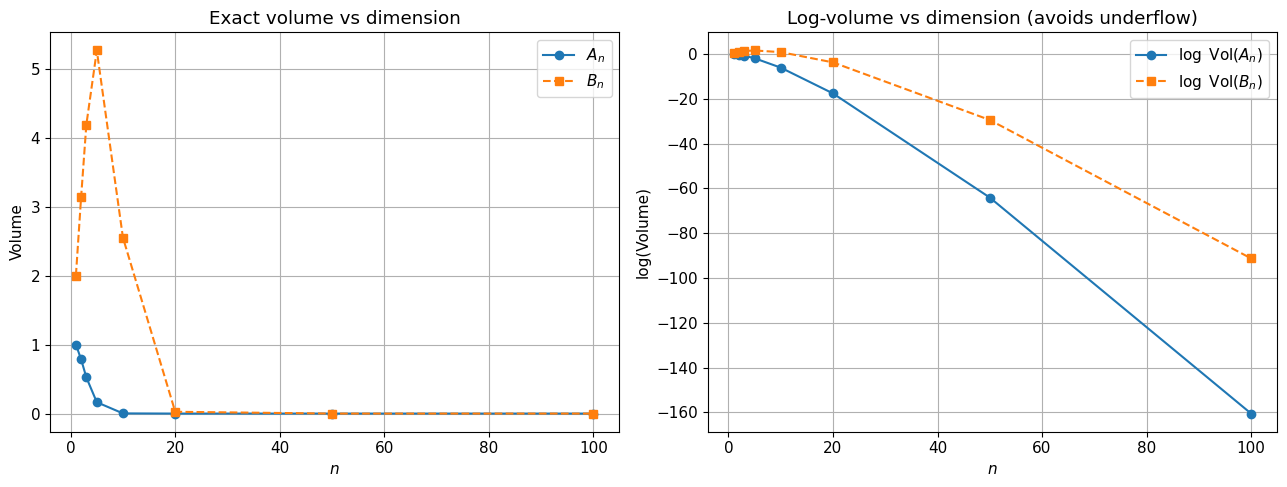

In [52]:
# ── Volume and log-volume plots across dimensions ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(et["n"], et["vol_A"],   "o-", label="$A_n$")
axes[0].plot(et["n"], et["vol_B"],   "s--", label="$B_n$")
axes[0].set(title="Exact volume vs dimension", xlabel="$n$", ylabel="Volume")
axes[0].legend()

axes[1].plot(et["n"], et["log_vol_A"], "o-", label="$\\log$ Vol$(A_n)$")
axes[1].plot(et["n"], et["log_vol_B"], "s--", label="$\\log$ Vol$(B_n)$")
axes[1].set(title="Log-volume vs dimension (avoids underflow)",
            xlabel="$n$", ylabel="log(Volume)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [53]:
# ── Monte Carlo at n=100 (expect 0 hits) ──────────────────────────────────────
rows_100 = []
for shape in ["A", "B"]:
    for N in [1_000, 10_000, 100_000]:
        rows_100.append(monte_carlo(shape, n=100, N=N, chunk=10_000))

df_100 = pd.DataFrame(rows_100)

# Log-exact from formula:
df_100["log_exact"] = df_100.apply(
    lambda r: log_vol_A(100) if r["shape"]=="A" else log_vol_B(100), axis=1)

df_100[["shape","n","N","hits","hit_rate","estimate","log_exact"]].to_string(index=False)
df_100[["shape","n","N","hits","hit_rate","estimate","log_exact"]]

,shape,n,N,hits,hit_rate,estimate,log_exact
0,A,100,1000,0,0.0,0.0,-160.555991
1,A,100,10000,0,0.0,0.0,-160.555991
2,A,100,100000,0,0.0,0.0,-160.555991
3,B,100,1000,0,0.0,0.0,-91.241273
4,B,100,10000,0,0.0,0.0,-91.241273
5,B,100,100000,0,0.0,0.0,-91.241273


---
## Recursive Slicing Improvement

Bounding-box Monte Carlo fails in high dimensions because the hit probability becomes too small to observe with practical sample sizes.  Recursive slicing replaces random hit counting with a one-dimensional cross-sectional integral:

$$
\mathrm{Vol}(B_n)=\mathrm{Vol}(B_{n-1})\int_{-1}^{1}(1-t^2)^{(n-1)/2}\,dt.
$$

The calculation is accumulated on the log scale, then shifted by $-n\log 2$ for $A_n$.


In [54]:
# ============================================================
# Recursive slicing / cross-sectional integration
# Problem 1 improvement method
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from scipy.integrate import quad
from scipy.special import gammaln


# ------------------------------------------------------------
# Exact log-volume by Gamma formula
# Used as benchmark
# ------------------------------------------------------------

def exact_log_volume_B(n):
    """
    Exact log-volume of the n-dimensional unit ball B_n.

    Vol(B_n) = pi^(n/2) / Gamma(n/2 + 1)
    """
    return (n / 2) * math.log(math.pi) - gammaln(n / 2 + 1)


def exact_log_volume_A(n):
    """
    Exact log-volume of A_n.

    A_n has radius 1/2, so:
    Vol(A_n) = 2^(-n) Vol(B_n)
    """
    return exact_log_volume_B(n) - n * math.log(2)


def safe_exp(log_value):
    """
    Convert log-value to normal scale safely.
    Returns 0 if the value underflows in floating point.
    """
    if log_value < -745:
        return 0.0
    return math.exp(log_value)


# ------------------------------------------------------------
# Cross-sectional integral
# ------------------------------------------------------------

def cross_section_integral(n, epsabs=1e-12, epsrel=1e-12):
    """
    Compute the 1D integral:

        I_n = integral from -1 to 1 of (1 - t^2)^((n-1)/2) dt

    Then:
        Vol(B_n) = Vol(B_{n-1}) * I_n
    """
    if n < 1:
        raise ValueError("n must be >= 1")

    exponent = (n - 1) / 2

    def integrand(t):
        return (1 - t * t) ** exponent

    value, error = quad(
        integrand,
        -1.0,
        1.0,
        epsabs=epsabs,
        epsrel=epsrel,
        limit=200
    )

    return value, error


def recursive_slicing_log_volume_B(n, epsabs=1e-12, epsrel=1e-12):
    """
    Compute log Vol(B_n) using recursive cross-sectional integration.

    Base case:
        Vol(B_0) = 1

    Recursive formula:
        Vol(B_k) = Vol(B_{k-1}) * I_k

    where:
        I_k = integral from -1 to 1 of (1 - t^2)^((k-1)/2) dt
    """
    if n < 0:
        raise ValueError("n must be >= 0")

    log_volume = 0.0  # log Vol(B_0) = log(1) = 0

    integral_errors = []

    for k in range(1, n + 1):
        integral_value, integral_error = cross_section_integral(
            k,
            epsabs=epsabs,
            epsrel=epsrel
        )

        log_volume += math.log(integral_value)

        integral_errors.append({
            "k": k,
            "integral_value": integral_value,
            "integral_error": integral_error
        })

    return log_volume, pd.DataFrame(integral_errors)


def recursive_slicing_log_volume_A(n, epsabs=1e-12, epsrel=1e-12):
    """
    Compute log Vol(A_n) from recursive slicing result for B_n.
    """
    log_B, error_df = recursive_slicing_log_volume_B(
        n,
        epsabs=epsabs,
        epsrel=epsrel
    )

    log_A = log_B - n * math.log(2)

    return log_A, error_df


In [55]:
# ============================================================
# Compare Gamma formula and recursive slicing
# ============================================================

slicing_dims = [1, 2, 3, 5, 10, 20, 50, 100]

slicing_rows = []

for n in slicing_dims:
    gamma_log_B = exact_log_volume_B(n)
    gamma_log_A = exact_log_volume_A(n)

    slicing_log_B, slicing_error_df = recursive_slicing_log_volume_B(n)
    slicing_log_A = slicing_log_B - n * math.log(2)

    slicing_rows.append({
        "n": n,

        "gamma_log_volume_B": gamma_log_B,
        "slicing_log_volume_B": slicing_log_B,
        "abs_log_error_B": abs(slicing_log_B - gamma_log_B),

        "gamma_log_volume_A": gamma_log_A,
        "slicing_log_volume_A": slicing_log_A,
        "abs_log_error_A": abs(slicing_log_A - gamma_log_A),

        "gamma_volume_B": safe_exp(gamma_log_B),
        "slicing_volume_B": safe_exp(slicing_log_B),

        "gamma_volume_A": safe_exp(gamma_log_A),
        "slicing_volume_A": safe_exp(slicing_log_A),

        "max_integral_error": slicing_error_df["integral_error"].max()
    })

slicing_summary = pd.DataFrame(slicing_rows)

display(slicing_summary)


,n,gamma_log_volume_B,slicing_log_volume_B,abs_log_error_B,gamma_log_volume_A,slicing_log_volume_A,abs_log_error_A,gamma_volume_B,slicing_volume_B,gamma_volume_A,slicing_volume_A,max_integral_error
0,1,0.693147,0.693147,1.110223e-16,1.110223e-16,0.000000,1.110223e-16,2.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,2.220446e-14
1,2,1.144730,1.144730,6.661338e-16,-2.415645e-01,-0.241564,6.661338e-16,3.141593e+00,3.141593e+00,7.853982e-01,7.853982e-01,2.575717e-14
2,3,1.432412,1.432412,6.661338e-16,-6.470296e-01,-0.647030,6.661338e-16,4.188790e+00,4.188790e+00,5.235988e-01,5.235988e-01,2.575717e-14
3,5,1.660851,1.660851,6.661338e-16,-1.804885e+00,-1.804885,6.661338e-16,5.263789e+00,5.263789e+00,1.644934e-01,1.644934e-01,5.646594e-13
4,10,0.936158,0.936158,3.552714e-15,-5.995314e+00,-5.995314,3.552714e-15,2.550164e+00,2.550164e+00,2.490395e-03,2.490395e-03,7.098862e-13
5,20,-3.657114,-3.657114,1.776357e-15,-1.752006e+01,-17.520057,0.000000e+00,2.580689e-02,2.580689e-02,2.461137e-08,2.461137e-08,7.098862e-13
6,50,-29.385358,-29.385358,7.105427e-15,-6.404272e+01,-64.042717,0.000000e+00,1.730219e-13,1.730219e-13,1.536743e-28,1.536743e-28,8.908054e-13
7,100,-91.241273,-91.241273,1.421085e-14,-1.605560e+02,-160.555991,2.842171e-14,2.368202e-40,2.368202e-40,1.868182e-70,1.868182e-70,8.908054e-13


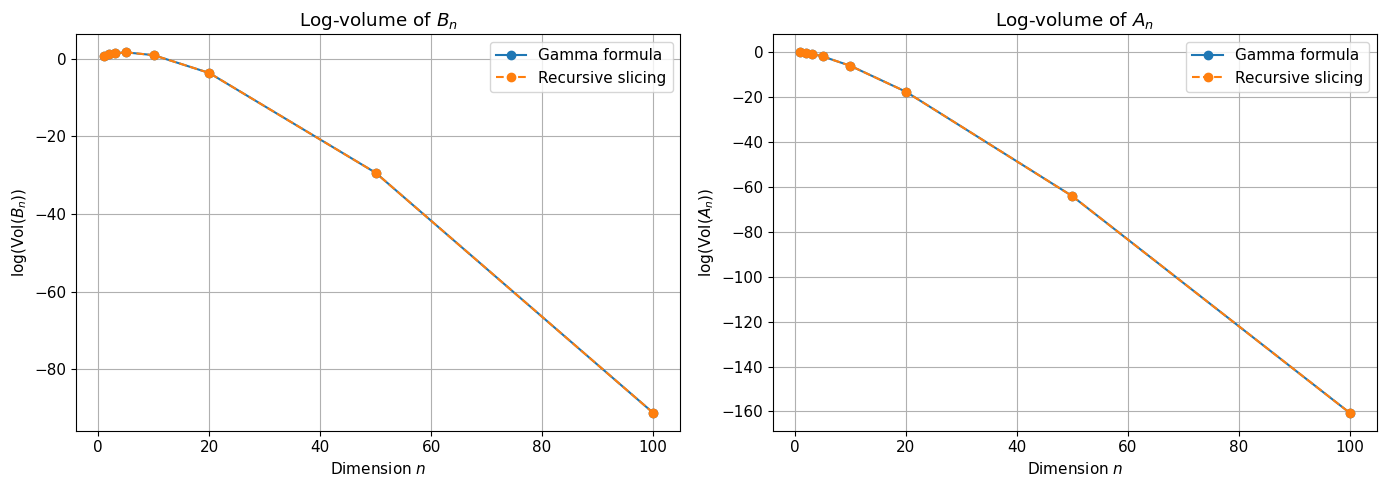

In [56]:
# ============================================================
# Plot log-volume comparison
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(
    slicing_summary["n"],
    slicing_summary["gamma_log_volume_B"],
    marker="o",
    label="Gamma formula"
)

ax[0].plot(
    slicing_summary["n"],
    slicing_summary["slicing_log_volume_B"],
    marker="o",
    linestyle="--",
    label="Recursive slicing"
)

ax[0].set_title("Log-volume of $B_n$")
ax[0].set_xlabel("Dimension $n$")
ax[0].set_ylabel("$\log(\mathrm{Vol}(B_n))$")
ax[0].legend()
ax[0].grid(True)


ax[1].plot(
    slicing_summary["n"],
    slicing_summary["gamma_log_volume_A"],
    marker="o",
    label="Gamma formula"
)

ax[1].plot(
    slicing_summary["n"],
    slicing_summary["slicing_log_volume_A"],
    marker="o",
    linestyle="--",
    label="Recursive slicing"
)

ax[1].set_title("Log-volume of $A_n$")
ax[1].set_xlabel("Dimension $n$")
ax[1].set_ylabel("$\log(\mathrm{Vol}(A_n))$")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()


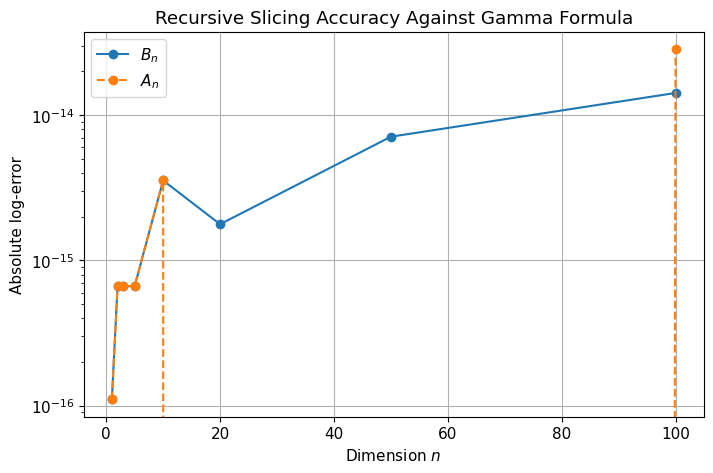

In [57]:
# ============================================================
# Plot absolute log-error of recursive slicing
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    slicing_summary["n"],
    slicing_summary["abs_log_error_B"],
    marker="o",
    label="$B_n$"
)

plt.plot(
    slicing_summary["n"],
    slicing_summary["abs_log_error_A"],
    marker="o",
    linestyle="--",
    label="$A_n$"
)

plt.yscale("log")
plt.title("Recursive Slicing Accuracy Against Gamma Formula")
plt.xlabel("Dimension $n$")
plt.ylabel("Absolute log-error")
plt.legend()
plt.grid(True)

plt.show()


In [58]:
# ============================================================
# High-dimensional improvement table
# ============================================================

n = 100

log_B_gamma = exact_log_volume_B(n)
log_A_gamma = exact_log_volume_A(n)

log_B_slicing, _ = recursive_slicing_log_volume_B(n)
log_A_slicing = log_B_slicing - n * math.log(2)

high_dim_improvement = pd.DataFrame([
    {
        "shape": "A_100",
        "method": "Bounding-box MC",
        "estimate": 0.0,
        "log_estimate": -np.inf,
        "comment": "Zero hits with practical N"
    },
    {
        "shape": "A_100",
        "method": "Recursive slicing",
        "estimate": safe_exp(log_A_slicing),
        "log_estimate": log_A_slicing,
        "comment": "Stable high-dimensional computation"
    },
    {
        "shape": "A_100",
        "method": "Gamma formula",
        "estimate": safe_exp(log_A_gamma),
        "log_estimate": log_A_gamma,
        "comment": "Exact benchmark"
    },
    {
        "shape": "B_100",
        "method": "Bounding-box MC",
        "estimate": 0.0,
        "log_estimate": -np.inf,
        "comment": "Zero hits with practical N"
    },
    {
        "shape": "B_100",
        "method": "Recursive slicing",
        "estimate": safe_exp(log_B_slicing),
        "log_estimate": log_B_slicing,
        "comment": "Stable high-dimensional computation"
    },
    {
        "shape": "B_100",
        "method": "Gamma formula",
        "estimate": safe_exp(log_B_gamma),
        "log_estimate": log_B_gamma,
        "comment": "Exact benchmark"
    }
])

display(high_dim_improvement)


,shape,method,estimate,log_estimate,comment
0,A_100,Bounding-box MC,0.000000e+00,-inf,Zero hits with practical N
1,A_100,Recursive slicing,1.868182e-70,-160.555991,Stable high-dimensional computation
2,A_100,Gamma formula,1.868182e-70,-160.555991,Exact benchmark
3,B_100,Bounding-box MC,0.000000e+00,-inf,Zero hits with practical N
4,B_100,Recursive slicing,2.368202e-40,-91.241273,Stable high-dimensional computation
5,B_100,Gamma formula,2.368202e-40,-91.241273,Exact benchmark


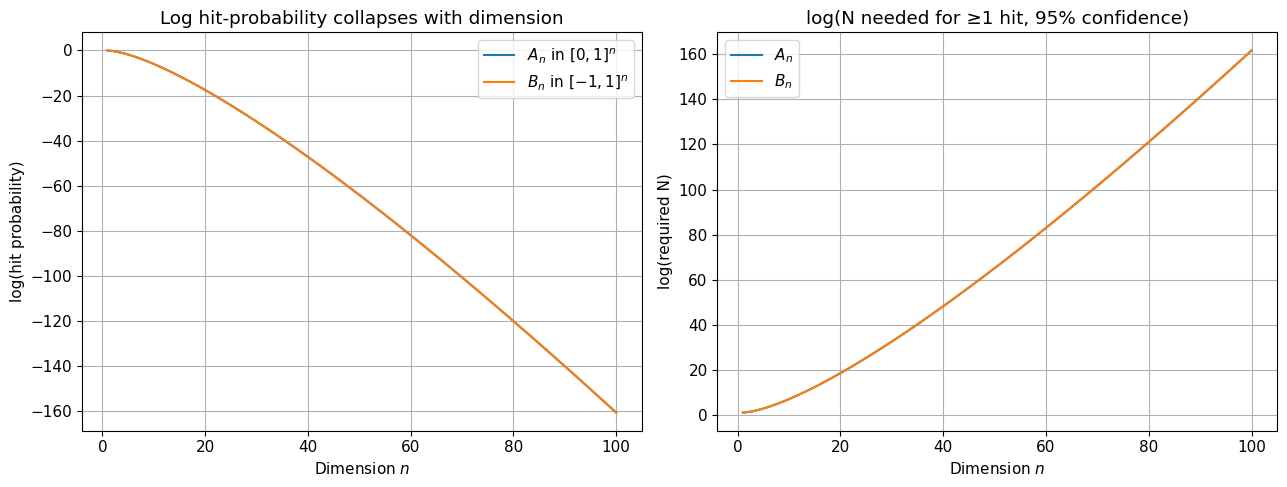

In [59]:
# ── Hit probability vs dimension ──────────────────────────────────────────────
dim_grid = np.arange(1, 101)
lhr_A = [log_vol_A(n)                    for n in dim_grid]  # box vol=1  for A
lhr_B = [log_vol_B(n) - n*math.log(2)   for n in dim_grid]  # box vol=2^n for B

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(dim_grid, lhr_A, label="$A_n$ in $[0,1]^n$")
axes[0].plot(dim_grid, lhr_B, label="$B_n$ in $[-1,1]^n$")
axes[0].set(title="Log hit-probability collapses with dimension",
            xlabel="Dimension $n$", ylabel="log(hit probability)")
axes[0].legend()

# Required N for ≥1 hit with 95% probability: N ≈ log(0.05)/log(1−p) ≈ 3/p
log_N_A = [-lp + math.log(-math.log(0.05)) for lp in lhr_A]
log_N_B = [-lp + math.log(-math.log(0.05)) for lp in lhr_B]

axes[1].plot(dim_grid, log_N_A, label="$A_n$")
axes[1].plot(dim_grid, log_N_B, label="$B_n$")
axes[1].set(title="log(N needed for ≥1 hit, 95% confidence)",
            xlabel="Dimension $n$", ylabel="log(required N)")
axes[1].legend()

plt.tight_layout()
plt.show()

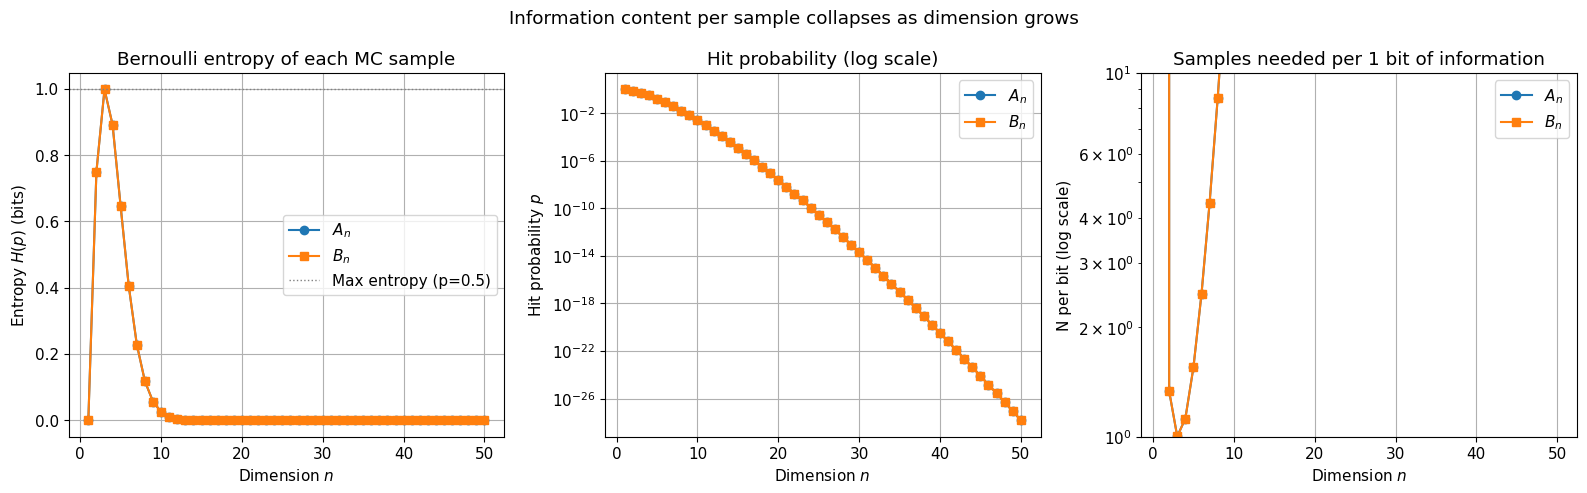

In [60]:
# ── Bernoulli entropy of the hit/miss process ─────────────────────────────────
# Placement: Notebook 1, Part 1.c — after hit-probability plot

def bernoulli_entropy(p):
    """Shannon entropy (bits) of a Bernoulli(p) trial."""
    if p <= 0 or p >= 1: return 0.0
    return -p * math.log2(p) - (1-p) * math.log2(1-p)

dim_grid = np.arange(1, 51)

# hit probabilities: for A_n the box has vol=1 so hit_prob = Vol(A_n)
# for B_n the box has vol=2^n so hit_prob = Vol(B_n)/2^n
log_hp_A = [log_vol_A(n)                    for n in dim_grid]
log_hp_B = [log_vol_B(n) - n*math.log(2)   for n in dim_grid]

hp_A = [math.exp(l) if l > -745 else 0.0 for l in log_hp_A]
hp_B = [math.exp(l) if l > -745 else 0.0 for l in log_hp_B]

ent_A = [bernoulli_entropy(p) for p in hp_A]
ent_B = [bernoulli_entropy(p) for p in hp_B]

# Bits needed to collect one "useful" hit: 1/H(p) * N_for_one_hit
# (how many samples before you get 1 bit of useful information)
info_per_N_A = [h/max(p, 1e-300) if p > 0 else 0 for h, p in zip(ent_A, hp_A)]
info_per_N_B = [h/max(p, 1e-300) if p > 0 else 0 for h, p in zip(ent_B, hp_B)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(dim_grid, ent_A, "o-", label="$A_n$")
axes[0].plot(dim_grid, ent_B, "s-", label="$B_n$")
axes[0].set(title="Bernoulli entropy of each MC sample",
            xlabel="Dimension $n$",
            ylabel="Entropy $H(p)$ (bits)")
axes[0].axhline(1.0, color="gray", ls=":", lw=1, label="Max entropy (p=0.5)")
axes[0].legend()

axes[1].semilogy(dim_grid, [max(p,1e-300) for p in hp_A], "o-", label="$A_n$")
axes[1].semilogy(dim_grid, [max(p,1e-300) for p in hp_B], "s-", label="$B_n$")
axes[1].set(title="Hit probability (log scale)",
            xlabel="Dimension $n$", ylabel="Hit probability $p$")
axes[1].legend()

# Samples needed to accumulate 1 bit of useful information
samples_for_1bit_A = [1/(max(e,1e-300)) for e in ent_A]
samples_for_1bit_B = [1/(max(e,1e-300)) for e in ent_B]
axes[2].semilogy(dim_grid, samples_for_1bit_A, "o-", label="$A_n$")
axes[2].semilogy(dim_grid, samples_for_1bit_B, "s-", label="$B_n$")
axes[2].set(title="Samples needed per 1 bit of information",
            xlabel="Dimension $n$", ylabel="N per bit (log scale)")
axes[2].legend()

plt.suptitle("Information content per sample collapses as dimension grows")
plt.tight_layout()
plt.show()

In [61]:
# ── Repeated MC: shows variance and zero-hit fraction ─────────────────────────
rep_dims  = [2, 3, 5, 10, 20]
rep_rows  = [repeated_mc(s, n) for s in ["A","B"] for n in rep_dims]
rep_df    = pd.DataFrame(rep_rows)

rep_df[["shape","n","mean","std","ci95","zero_hit_frac"]].round(6)

,shape,n,mean,std,ci95,zero_hit_frac
0,A,2,0.785673,0.004013,0.001436,0.0
1,A,3,0.523067,0.004217,0.001509,0.0
2,A,5,0.164917,0.004263,0.001526,0.0
3,A,10,0.002540,0.000512,0.000183,0.0
4,A,20,0.000000,0.000000,0.000000,1.0
5,B,2,3.142693,0.016051,0.005744,0.0
6,B,3,4.184533,0.033738,0.012073,0.0
7,B,5,5.277333,0.136424,0.048819,0.0
8,B,10,2.600960,0.523937,0.187488,0.0
9,B,20,0.000000,0.000000,0.000000,1.0


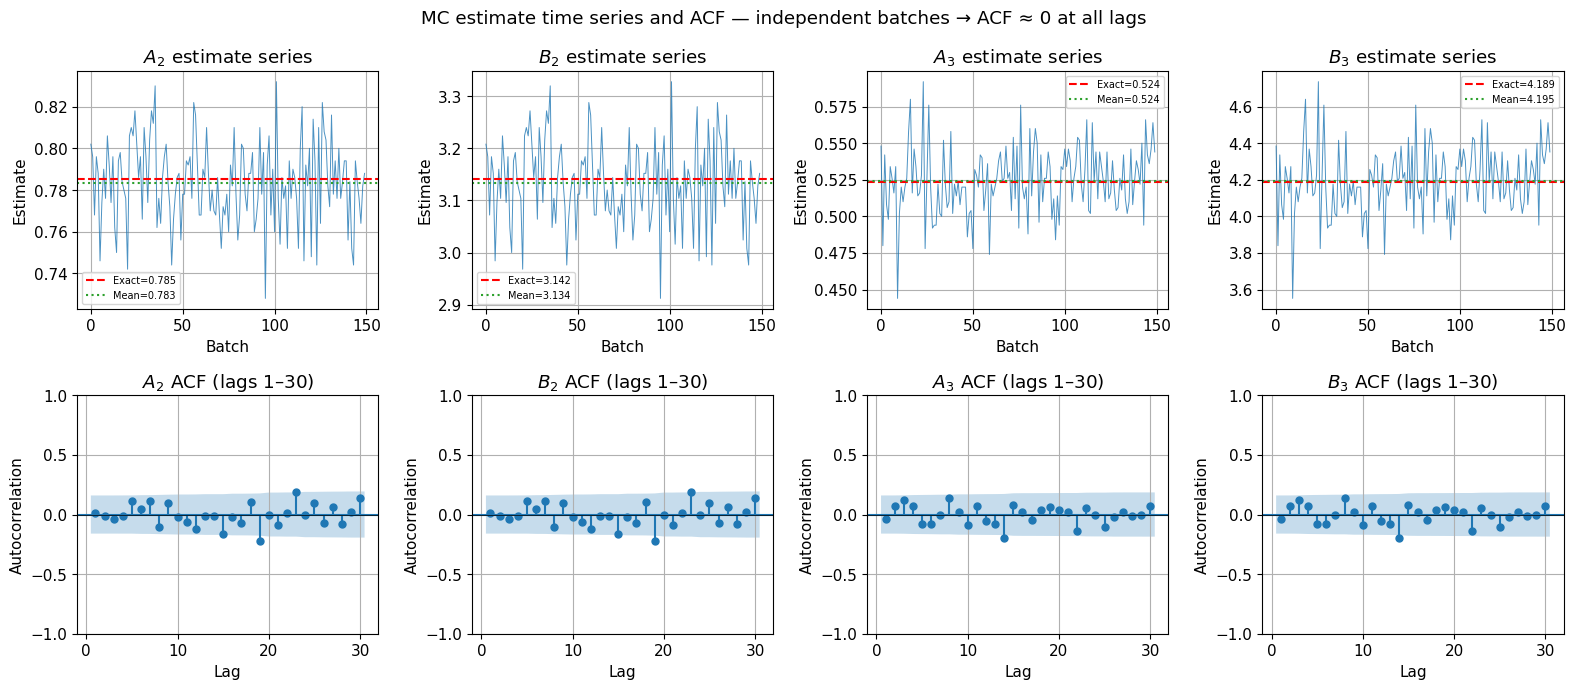


Time-series summary:
  A_2: mean=0.78348  std=0.01985  exact=0.78540  lag-1 ACF=0.0092
  B_2: mean=3.13392  std=0.07938  exact=3.14159  lag-1 ACF=0.0092
  A_3: mean=0.52432  std=0.02279  exact=0.52360  lag-1 ACF=-0.0365
  B_3: mean=4.19456  std=0.18235  exact=4.18879  lag-1 ACF=-0.0365


In [62]:
# ── MC estimate time series and ACF ──────────────────────────────────────────
# Placement: Notebook 1, after rep_df block
from statsmodels.graphics.tsaplots import plot_acf

def mc_estimate_series(shape, n, N_per_batch=1000, n_batches=200, seed=SEED):
    """
    Run MC in consecutive batches. Returns an (n_batches,) array of estimates —
    one per batch. Used to check independence via ACF and visualise estimator
    variance as a time series.
    """
    rng = np.random.default_rng(seed)
    series = []
    for _ in range(n_batches):
        if shape == "A":
            x   = rng.uniform(0, 1, (N_per_batch, n))
            est = float(in_A(x).mean())             # box vol = 1
        else:
            x   = rng.uniform(-1, 1, (N_per_batch, n))
            est = float((2**n) * in_B(x).mean())
        series.append(est)
    return np.array(series)


fig, axes = plt.subplots(2, 4, figsize=(16, 7))
configs   = [("A",2), ("B",2), ("A",3), ("B",3)]

for col, (shape, n) in enumerate(configs):
    exact = exact_vol(shape, n)
    ts    = mc_estimate_series(shape, n, N_per_batch=500, n_batches=150)

    # Top row: time series
    ax = axes[0, col]
    ax.plot(ts, lw=0.7, alpha=0.8)
    ax.axhline(exact, color="red", ls="--", lw=1.5, label=f"Exact={exact:.3f}")
    ax.axhline(ts.mean(), color="C2", ls=":", lw=1.5, label=f"Mean={ts.mean():.3f}")
    ax.set(title=f"${shape}_{n}$ estimate series",
           xlabel="Batch", ylabel="Estimate")
    ax.legend(fontsize=7)

    # Bottom row: ACF
    ax = axes[1, col]
    plot_acf(ts, ax=ax, lags=30, alpha=0.05, zero=False)
    ax.set(title=f"${shape}_{n}$ ACF (lags 1–30)",
           xlabel="Lag", ylabel="Autocorrelation")
    ax.axhline(0, color="k", lw=0.5)

plt.suptitle("MC estimate time series and ACF — independent batches → ACF ≈ 0 at all lags")
plt.tight_layout()
plt.show()

# Summary: mean, std, and first-lag ACF across shapes/dims
print("\nTime-series summary:")
for shape, n in configs:
    ts  = mc_estimate_series(shape, n, N_per_batch=500, n_batches=150)
    lag1_acf = float(np.corrcoef(ts[:-1], ts[1:])[0,1])
    print(f"  {shape}_{n}: mean={ts.mean():.5f}  std={ts.std():.5f}  "
          f"exact={exact_vol(shape,n):.5f}  lag-1 ACF={lag1_acf:.4f}")

In [ ]:
# ── Variance scaling: empirical std vs theoretical 1/sqrt(N) ─────────────────
# Placement: Notebook 1, directly after the ACF block above

def variance_scaling(shape, n, N_list=(100, 500, 1_000, 5_000, 10_000),
                     repeats=60, seed=SEED):
    """
    For each N: run `repeats` independent MC estimates, record empirical std.
    Also compute the theoretical std = sqrt(p*(1-p)/N) * box_vol.
    """
    rows = []
    for N in N_list:
        estimates = []
        for k in range(repeats):
            rng = np.random.default_rng(seed + k + N)
            if shape == "A":
                x = rng.uniform(0, 1, (N, n))
                estimates.append(float(in_A(x).mean()))
            else:
                x = rng.uniform(-1, 1, (N, n))
                estimates.append(float((2**n) * in_B(x).mean()))
        arr = np.array(estimates)

        # Theoretical: Var(estimator) = box_vol^2 * p*(1-p) / N
        log_p = log_vol_A(n) if shape == "A" else log_vol_B(n) - n*math.log(2)
        p     = math.exp(log_p) if log_p > -745 else 0.0
        box   = 1.0 if shape == "A" else 2**n
        theo_std = box * math.sqrt(p * (1-p) / N) if p > 0 else 0.0

        rows.append(dict(shape=shape, n=n, N=N,
                         empirical_std=arr.std(ddof=1),
                         theoretical_std=theo_std,
                         ratio=arr.std(ddof=1)/theo_std if theo_std > 0 else float("nan")))
    return pd.DataFrame(rows)


fig, axes = plt.subplots(2, 2, figsize=(13, 9))
N_list = [100, 500, 1_000, 5_000, 10_000]

for ax, (shape, n) in zip(axes.flat, [("A",2),("B",2),("A",3),("B",3)]):
    df_v = variance_scaling(shape, n, N_list=N_list)
    ax.loglog(df_v["N"], df_v["empirical_std"],  "o-",  label="Empirical std")
    ax.loglog(df_v["N"], df_v["theoretical_std"],"s--", label="Theoretical $\\sigma/\\sqrt{N}$")

    # Reference slope line
    N_arr = np.array(N_list, dtype=float)
    ref   = df_v["empirical_std"].iloc[0] * (N_list[0] / N_arr)**0.5
    ax.loglog(N_arr, ref, "k:", lw=1, label="Slope $-1/2$ reference")

    ax.set(title=f"${shape}_{n}$ — std scaling",
           xlabel="N (log)", ylabel="Std of estimate (log)")
    ax.legend(fontsize=9)

plt.suptitle("Empirical vs theoretical MC variance scaling — should follow $1/\\sqrt{N}$")
plt.tight_layout()
plt.show()

# Print ratio table (should be ≈ 1.0 if theory matches)
print("\nRatio empirical/theoretical (should ≈ 1.0):")
for shape, n in [("A",2),("B",2),("A",3),("B",3)]:
    df_v = variance_scaling(shape, n, N_list=N_list)
    print(f"  {shape}_{n}: " + "  ".join(f"N={r.N}: {r.ratio:.3f}" for _, r in df_v.iterrows()))

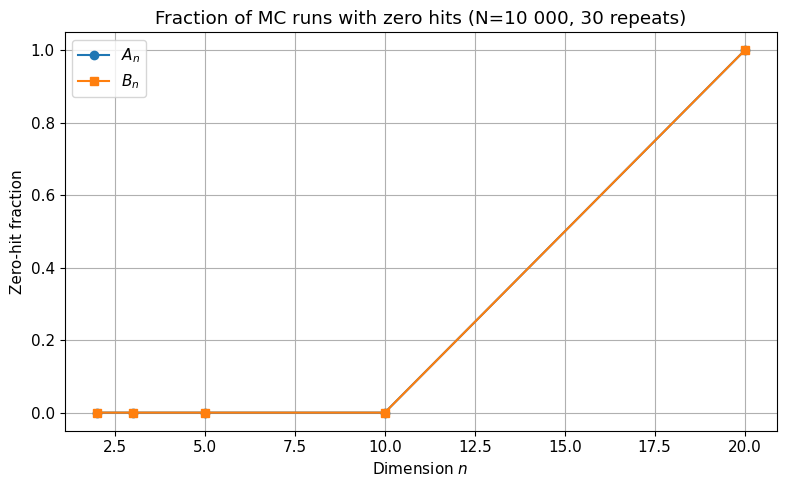

In [ ]:
# ── Zero-hit fraction plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

for s, marker in [("A","o"), ("B","s")]:
    sub = rep_df[rep_df["shape"]==s]
    ax.plot(sub["n"], sub["zero_hit_frac"], marker+"-", label=f"${s}_n$")

ax.set(title="Fraction of MC runs with zero hits (N=10 000, 30 repeats)",
       xlabel="Dimension $n$", ylabel="Zero-hit fraction", ylim=(-0.05, 1.05))
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Sobol quasi-MC comparison across dimensions ───────────────────────────────
qmc_dims = [2, 3, 5, 10, 20]
qmc_rows = [quasi_mc(s, n) for s in ["A","B"] for n in qmc_dims]
qmc_df   = pd.DataFrame(qmc_rows)

qmc_df[["shape","n","N","exact","estimate","abs_error","rel_error"]].round(6)

,shape,n,N,exact,estimate,abs_error,rel_error
0,A,2,8192,0.785398,0.785522,0.000124,0.000158
1,A,3,8192,0.523599,0.524902,0.001304,0.002490
2,A,5,8192,0.164493,0.162354,0.002140,0.013009
3,A,10,8192,0.002490,0.002075,0.000415,0.166720
4,A,20,8192,0.000000,0.000000,0.000000,1.000000
5,B,2,8192,3.141593,3.142090,0.000497,0.000158
6,B,3,8192,4.188790,4.199219,0.010429,0.002490
7,B,5,8192,5.263789,5.195312,0.068477,0.013009
8,B,10,8192,2.550164,2.125000,0.425164,0.166720
9,B,20,8192,0.025807,0.000000,0.025807,1.000000


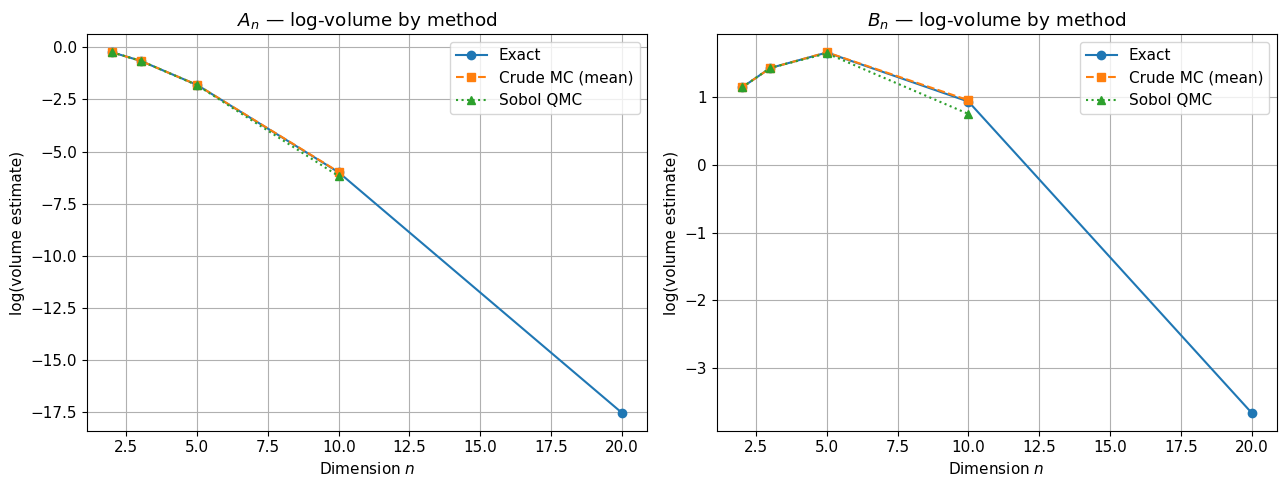

In [ ]:
# ── Method comparison: crude MC vs Sobol QMC (log-volume view) ───────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, s in zip(axes, ["A","B"]):
    ns   = np.array(qmc_dims)
    lv_exact = [log_vol_A(n) if s=="A" else log_vol_B(n) for n in ns]

    # crude MC mean from rep_df
    sub_r = rep_df[rep_df["shape"]==s].set_index("n")
    crude_means = [sub_r.loc[n,"mean"] for n in ns]
    lv_crude = [math.log(m) if m > 0 else -np.inf for m in crude_means]

    # Sobol
    sub_q = qmc_df[qmc_df["shape"]==s].set_index("n")
    lv_qmc = [math.log(sub_q.loc[n,"estimate"]) if sub_q.loc[n,"estimate"]>0 else -np.inf
              for n in ns]

    ax.plot(ns, lv_exact, "o-",  label="Exact")
    ax.plot(ns, lv_crude, "s--", label="Crude MC (mean)")
    ax.plot(ns, lv_qmc,   "^:",  label="Sobol QMC")
    ax.set(title=f"${s}_n$ — log-volume by method",
           xlabel="Dimension $n$", ylabel="log(volume estimate)")
    ax.legend()

plt.tight_layout()
plt.show()

## Curse of Dimensionality Analysis

The bounding-box Monte Carlo method works by sampling points from the surrounding box and counting how many fall inside the ball.

For $A_n$, the bounding box is $[0,1]^n$, whose volume is 1. Therefore,

$P(\text{hit } A_n) = \text{Vol}(A_n)$

For \(B_n\), the bounding box is \([-1,1]^n\), whose volume is \(2^n\). Therefore,

$P(\text{hit } B_n) = \frac{\text{Vol}(B_n)}{2^n}$

Since

$\text{Vol}(A_n) = \frac{\text{Vol}(B_n)}{2^n}$

both methods have the same theoretical hit probability.

As $n$ increases, this hit probability collapses rapidly. This explains why the Monte Carlo estimator works well for $n=2$ and $n=3$, but usually returns zero hits for $n=100$.

In [ ]:
# ============================================================
# Curse of dimensionality: theoretical hit probability
# ============================================================

curse_dims = (2, 3, 5, 10, 20, 50, 100)

curse_rows = []

for n in curse_dims:
    lA, lB = log_vol_A(n), log_vol_B(n)

    # For A_n, bounding box volume is 1.
    log_hit_A = lA

    # For B_n, bounding box volume is 2^n.
    log_hit_B = lB - n * np.log(2)

    curse_rows.append({
        "n": n,
        "log_volume_A": lA,
        "log_volume_B": lB,
        "log_hit_rate_A": log_hit_A,
        "log_hit_rate_B": log_hit_B,
        "hit_rate_A": np.exp(log_hit_A) if log_hit_A > -745 else 0.0,
        "hit_rate_B": np.exp(log_hit_B) if log_hit_B > -745 else 0.0,
        "log10_hit_rate_A": log_hit_A / np.log(10),
        "log10_hit_rate_B": log_hit_B / np.log(10),
    })

hit_rate_df = pd.DataFrame(curse_rows)

display(hit_rate_df)

,n,log_volume_A,log_volume_B,log_hit_rate_A,log_hit_rate_B,hit_rate_A,hit_rate_B,log10_hit_rate_A,log10_hit_rate_B
0,2,-0.241564,1.144730,-0.241564,-0.241564,7.853982e-01,7.853982e-01,-0.104910,-0.104910
1,3,-0.647030,1.432412,-0.647030,-0.647030,5.235988e-01,5.235988e-01,-0.281001,-0.281001
2,5,-1.804885,1.660851,-1.804885,-1.804885,1.644934e-01,1.644934e-01,-0.783852,-0.783852
3,10,-5.995314,0.936158,-5.995314,-5.995314,2.490395e-03,2.490395e-03,-2.603732,-2.603732
4,20,-17.520057,-3.657114,-17.520057,-17.520057,2.461137e-08,2.461137e-08,-7.608864,-7.608864
5,50,-64.042717,-29.385358,-64.042717,-64.042717,1.536743e-28,1.536743e-28,-27.813399,-27.813399
6,100,-160.555991,-91.241273,-160.555991,-160.555991,1.868182e-70,1.868182e-70,-69.728581,-69.728581


In [ ]:
# ============================================================
# Samples needed for at least one hit with 95% probability
# ============================================================

required_rows = []

for _, row in hit_rate_df.iterrows():
    n = int(row["n"])

    for shape_name in ["A", "B"]:
        log_hit = row[f"log_hit_rate_{shape_name}"]

        # For small p, log_N_95 ≈ log(-log(0.05)) - log(p)
        # This is more stable than computing p directly.
        log_N_95 = np.log(-np.log(0.05)) - log_hit

        required_rows.append({
            "shape": shape_name,
            "n": n,
            "log_N_95_one_hit": log_N_95,
            "log10_N_95_one_hit": log_N_95 / np.log(10)
        })

required_N_table = pd.DataFrame(required_rows)

display(required_N_table)

,shape,n,log_N_95_one_hit,log10_N_95_one_hit
0,A,2,1.338753,0.581413
1,B,2,1.338753,0.581413
2,A,3,1.744218,0.757504
3,B,3,1.744218,0.757504
4,A,5,2.902073,1.260355
5,B,5,2.902073,1.260355
6,A,10,7.092503,3.080235
7,B,10,7.092503,3.080235
8,A,20,18.617246,8.085367
9,B,20,18.617246,8.085367


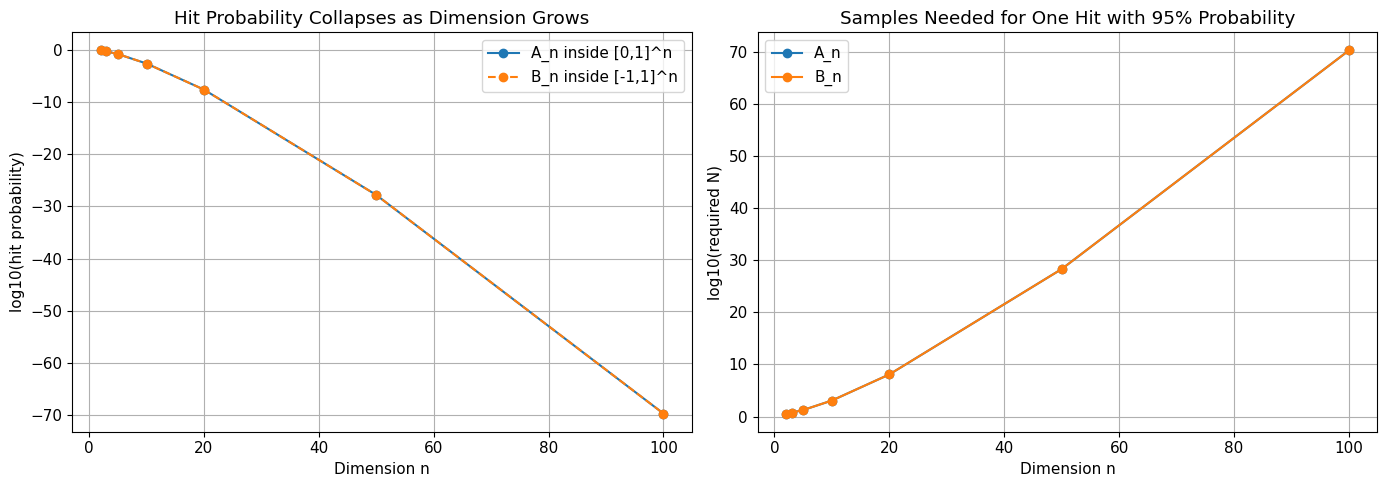

In [ ]:
# ============================================================
# Plot curse of dimensionality
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot hit probability collapse
ax[0].plot(
    hit_rate_df["n"],
    hit_rate_df["log10_hit_rate_A"],
    marker="o",
    label="A_n inside [0,1]^n"
)

ax[0].plot(
    hit_rate_df["n"],
    hit_rate_df["log10_hit_rate_B"],
    marker="o",
    linestyle="--",
    label="B_n inside [-1,1]^n"
)

ax[0].set_title("Hit Probability Collapses as Dimension Grows")
ax[0].set_xlabel("Dimension n")
ax[0].set_ylabel("log10(hit probability)")
ax[0].legend()
ax[0].grid(True)

# Plot required sample size
for shape_name in ["A", "B"]:
    sub = required_N_table[required_N_table["shape"] == shape_name]

    ax[1].plot(
        sub["n"],
        sub["log10_N_95_one_hit"],
        marker="o",
        label=f"{shape_name}_n"
    )

ax[1].set_title("Samples Needed for One Hit with 95% Probability")
ax[1].set_xlabel("Dimension n")
ax[1].set_ylabel("log10(required N)")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

---
## Method 5 — Direct Radial Sampling

Instead of sampling a bounding box and rejecting misses, we generate points
**uniformly inside the ball directly** using the Muller–Marsaglia method:

1. Draw $Z \sim \mathcal{N}(0, I_n)$ and normalise: $U = Z / \|Z\|$ (uniform direction on the sphere).
2. Draw $t \sim \text{Uniform}(0,1)$ and set $R = r \cdot t^{1/n}$ (correct radial density for an $n$-ball of radius $r$).
3. Return $X = R \cdot U$ (plus center for $A_n$).

**Key insight:** This avoids rejection entirely, so every sample is useful.  
**Important limitation:** Because it samples *inside* the ball by construction,
it cannot measure what fraction of the bounding box the ball occupies —
so it **does not estimate the volume on its own**.

In [ ]:
def radial_samples(shape: str, n: int, N: int = 4096, seed: int = SEED) -> np.ndarray:
    """
    Generate N points uniformly inside A_n (radius 0.5) or B_n (radius 1)
    using the Muller–Marsaglia direct method. Returns an (N, n) array.
    """
    rng = np.random.default_rng(seed)
    radius = 0.5 if shape == "A" else 1.0
    center = np.full(n, 0.5) if shape == "A" else np.zeros(n)

    Z = rng.standard_normal((N, n))               # random directions
    U = Z / np.linalg.norm(Z, axis=1, keepdims=True)  # normalise to sphere
    R = radius * rng.uniform(size=N) ** (1 / n)   # correct radial density
    return center + R[:, None] * U                # shift for A_n


print("radial_samples() defined.")
print("Sanity check — all generated points should be inside the ball:")
for shape, checker in [("A", in_A), ("B", in_B)]:
    pts = radial_samples(shape, n=3, N=5000)
    frac = checker(pts).mean()
    print(f"  {shape}_3 : {frac*100:.1f}% inside  (expected 100%)")

radial_samples() defined.
Sanity check — all generated points should be inside the ball:
  A_3 : 100.0% inside  (expected 100%)
  B_3 : 100.0% inside  (expected 100%)


### 5.1 Geometry visualisation — where do the samples land?

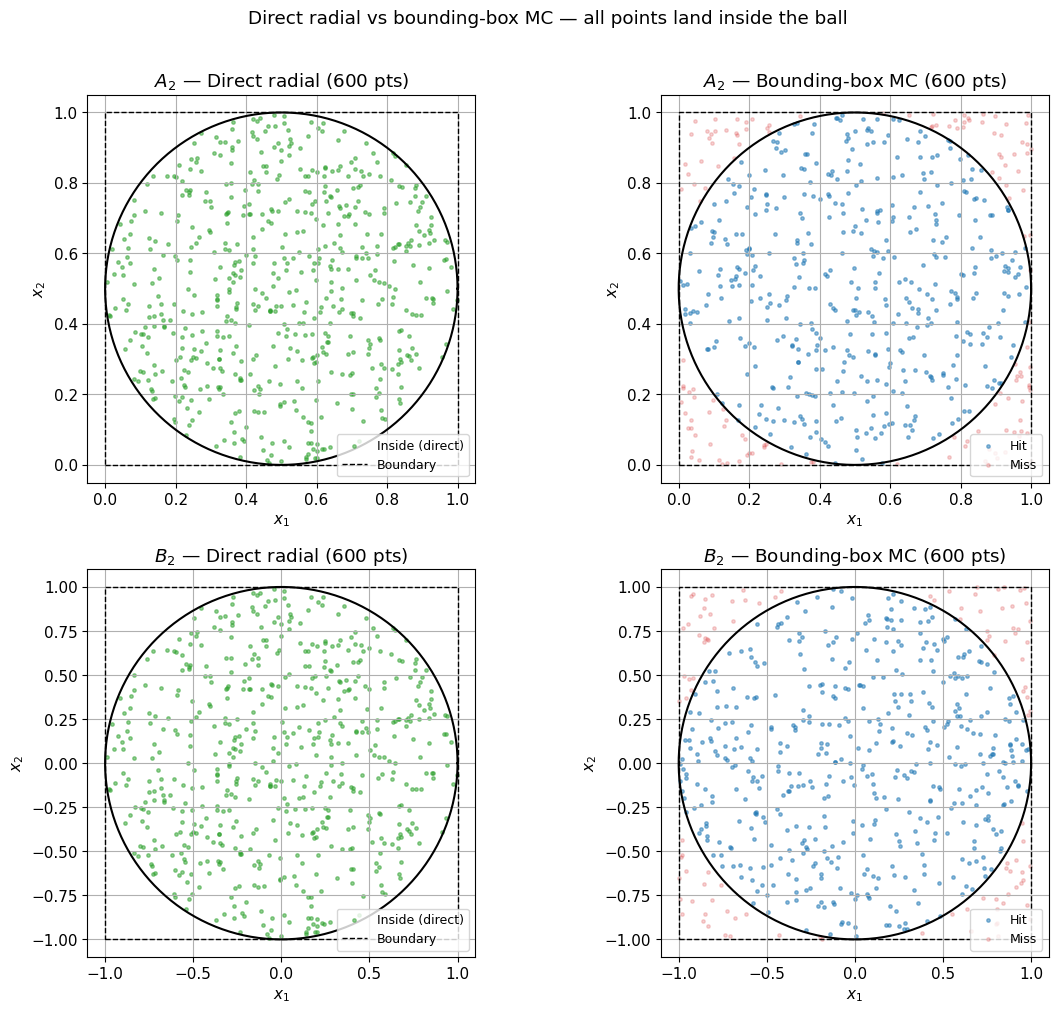

In [ ]:
# ── 2D scatter: direct radial vs bounding-box MC ──────────────────────────────
N_vis = 600
rng_vis = np.random.default_rng(SEED + 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
theta = np.linspace(0, 2*np.pi, 300)

for row, shape in enumerate(["A", "B"]):
    # Direct radial
    pts_radial = radial_samples(shape, n=2, N=N_vis)
    ax = axes[row, 0]
    ax.scatter(*pts_radial.T, s=6, alpha=0.5, color="C2", label="Inside (direct)")
    if shape == "A":
        ax.plot(0.5+0.5*np.cos(theta), 0.5+0.5*np.sin(theta), "k-", lw=1.5)
        ax.plot([0,1,1,0,0],[0,0,1,1,0],"k--",lw=1, label="Boundary")
    else:
        ax.plot(np.cos(theta), np.sin(theta), "k-", lw=1.5)
        ax.plot([-1,1,1,-1,-1],[-1,-1,1,1,-1],"k--",lw=1, label="Boundary")
    ax.set(title=f"${shape}_2$ — Direct radial ({N_vis} pts)",
           xlabel="$x_1$", ylabel="$x_2$", aspect="equal")
    ax.legend(fontsize=9)

    # Bounding-box MC (for comparison)
    if shape == "A":
        box_pts = rng_vis.uniform(0, 1, (N_vis, 2))
        mask    = in_A(box_pts)
    else:
        box_pts = rng_vis.uniform(-1, 1, (N_vis, 2))
        mask    = in_B(box_pts)
    ax = axes[row, 1]
    ax.scatter(*box_pts[ mask].T, s=6, alpha=0.5, color="C0", label="Hit")
    ax.scatter(*box_pts[~mask].T, s=6, alpha=0.2, color="C3", label="Miss")
    if shape == "A":
        ax.plot(0.5+0.5*np.cos(theta), 0.5+0.5*np.sin(theta), "k-", lw=1.5)
        ax.plot([0,1,1,0,0],[0,0,1,1,0],"k--",lw=1)
    else:
        ax.plot(np.cos(theta), np.sin(theta), "k-", lw=1.5)
        ax.plot([-1,1,1,-1,-1],[-1,-1,1,1,-1],"k--",lw=1)
    ax.set(title=f"${shape}_2$ — Bounding-box MC ({N_vis} pts)",
           xlabel="$x_1$", ylabel="$x_2$", aspect="equal")
    ax.legend(fontsize=9)

plt.suptitle("Direct radial vs bounding-box MC — all points land inside the ball", y=1.01)
plt.tight_layout()
plt.show()

### 5.2 Concentration of measure — radial distribution across dimensions

In high dimensions the sampled radii concentrate near the boundary of the ball
(a consequence of the radial density $f(r) \propto r^{n-1}$).
This is the geometric face of the curse of dimensionality.

In [ ]:
dims = [2, 3, 5, 10, 20, 50, 100]
N_radial = 5000

rows_radial = []
for shape in ["A", "B"]:
    radius = 0.5 if shape == "A" else 1.0
    for n in dims:
        pts  = radial_samples(shape, n=n, N=N_radial)
        center = np.full(n, 0.5) if shape == "A" else np.zeros(n)
        R    = np.linalg.norm(pts - center, axis=1)
        rows_radial.append(dict(
            shape=shape, n=n,
            mean_R=R.mean(), std_R=R.std(),
            median_R=np.median(R),
            frac_near_boundary=(R >= 0.9*radius).mean(),  # within 10% of edge
        ))

df_radial = pd.DataFrame(rows_radial)
df_radial.round(4)

,shape,n,mean_R,std_R,median_R,frac_near_boundary
0,A,2,0.3313,0.1186,0.3494,0.1908
1,A,3,0.3748,0.0975,0.3976,0.2708
2,A,5,0.4163,0.0706,0.4355,0.3996
3,A,10,0.4553,0.0408,0.4668,0.6556
4,A,20,0.4763,0.0225,0.4832,0.8812
5,A,50,0.4903,0.0094,0.4931,0.9966
6,A,100,0.4951,0.0047,0.4966,1.0000
7,B,2,0.6625,0.2372,0.6988,0.1908
8,B,3,0.7496,0.1950,0.7952,0.2708
9,B,5,0.8327,0.1412,0.8710,0.3996


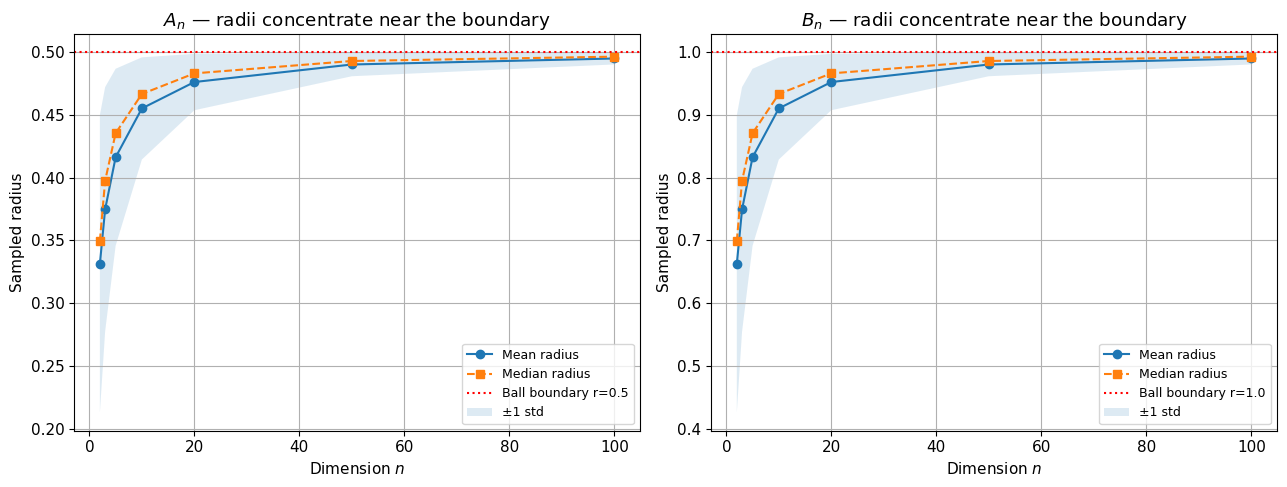

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, shape, radius in zip(axes, ["A","B"], [0.5, 1.0]):
    sub = df_radial[df_radial["shape"]==shape]
    ax.plot(sub["n"], sub["mean_R"],   "o-",  label="Mean radius")
    ax.plot(sub["n"], sub["median_R"], "s--", label="Median radius")
    ax.axhline(radius, color="red", ls=":", label=f"Ball boundary r={radius}")
    ax.fill_between(sub["n"],
                    sub["mean_R"] - sub["std_R"],
                    sub["mean_R"] + sub["std_R"],
                    alpha=0.15, label="±1 std")
    ax.set(title=f"${shape}_n$ — radii concentrate near the boundary",
           xlabel="Dimension $n$", ylabel="Sampled radius")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

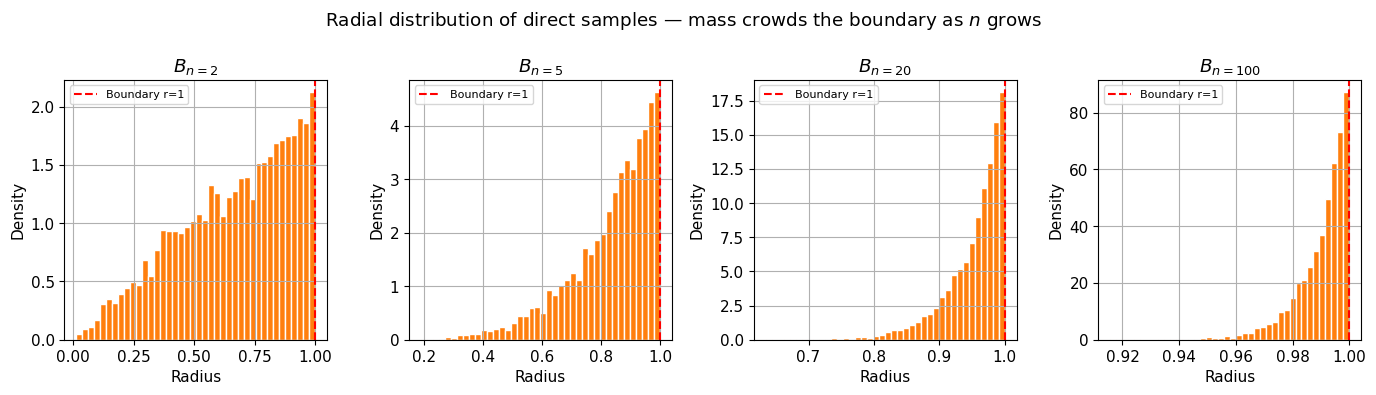

In [ ]:
# ── Histogram of radii at selected dimensions (B_n) ───────────────────────────
select_dims = [2, 5, 20, 100]
fig, axes = plt.subplots(1, len(select_dims), figsize=(14, 4), sharey=False)

for ax, n in zip(axes, select_dims):
    pts = radial_samples("B", n=n, N=N_radial)
    R   = np.linalg.norm(pts, axis=1)
    ax.hist(R, bins=40, color="C1", edgecolor="white", density=True)
    ax.axvline(1.0, color="red", ls="--", label="Boundary r=1")
    ax.set(title=f"$B_{{n={n}}}$", xlabel="Radius", ylabel="Density")
    ax.legend(fontsize=8)

plt.suptitle("Radial distribution of direct samples — mass crowds the boundary as $n$ grows")
plt.tight_layout()
plt.show()

     n    mean     std      cv
0    2  1.0059  0.4780  0.4752
1    3  1.2971  0.4879  0.3762
2    5  1.7409  0.4907  0.2819
3   10  2.5464  0.4886  0.1919
4   20  3.6309  0.4805  0.1323
5   50  5.7837  0.4808  0.0831
6  100  8.1505  0.4770  0.0585


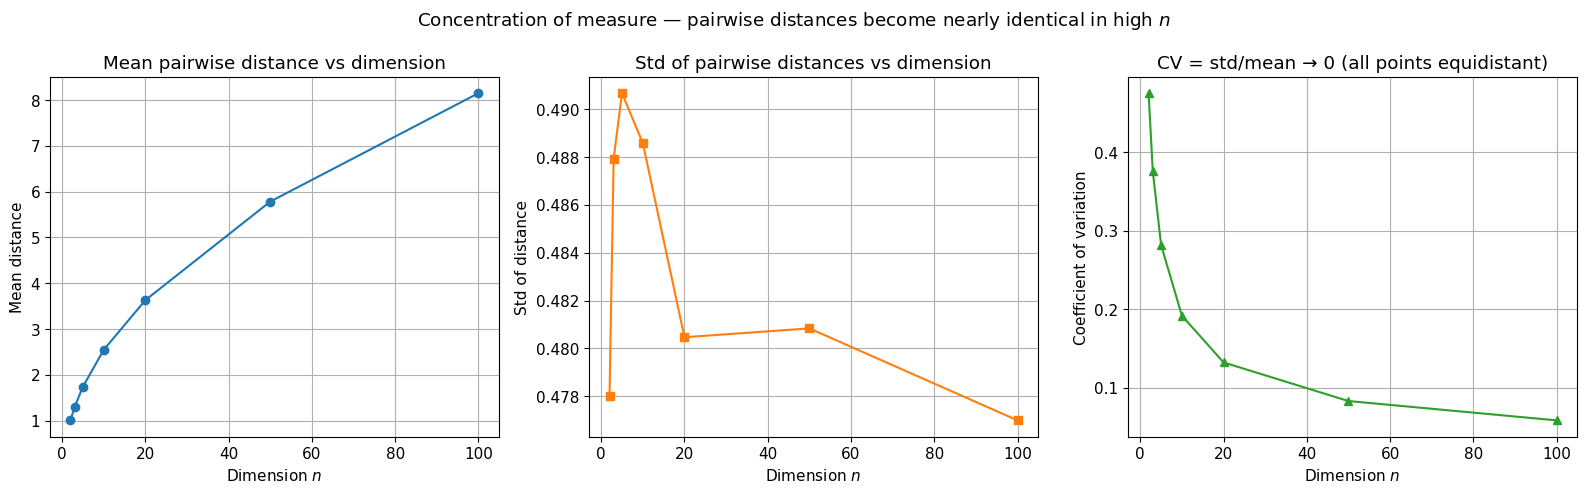

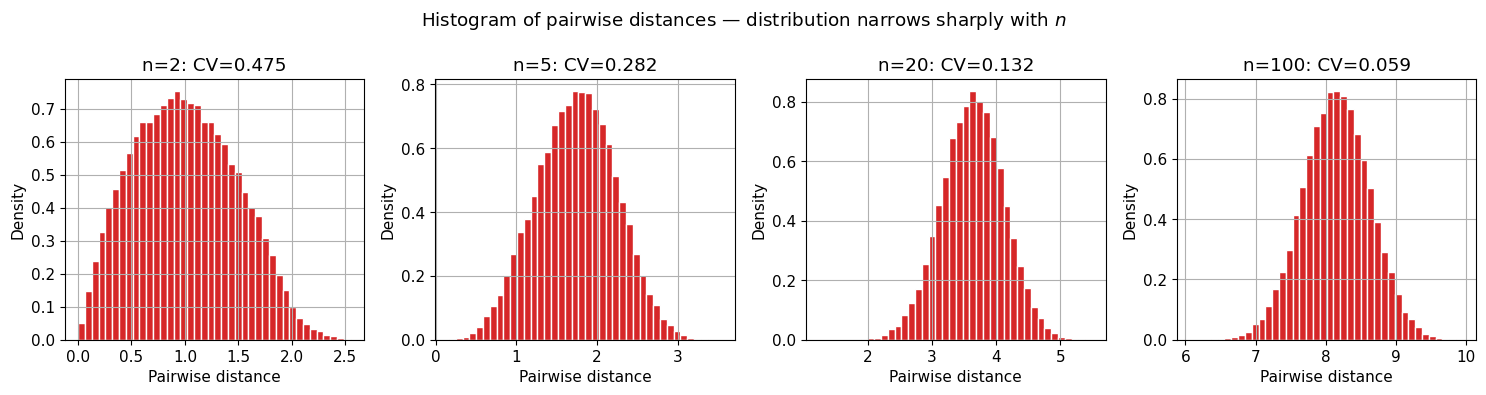

In [ ]:
# ── Concentration of measure: pairwise distance distribution ─────────────────
# Placement: Notebook 2, after the radial histogram block (end of Method 5)

def pairwise_dist_stats(n, N=300, from_box=True, seed=SEED):
    """
    Sample N points uniformly from [-1,1]^n and compute all pairwise distances.
    Returns (mean, std, cv=std/mean).
    from_box=True: uniform box samples.
    """
    rng = np.random.default_rng(seed)
    x   = rng.uniform(-1, 1, (N, n))
    diffs = x[:, None, :] - x[None, :, :]          # (N, N, n)
    dists = np.linalg.norm(diffs, axis=-1)           # (N, N)
    upper = dists[np.triu_indices(N, k=1)]           # upper triangle only
    return dict(n=n, mean=upper.mean(), std=upper.std(), cv=upper.std()/upper.mean())

dim_list = [2, 3, 5, 10, 20, 50, 100]
stats_rows = [pairwise_dist_stats(n) for n in dim_list]
df_dist = pd.DataFrame(stats_rows)
print(df_dist.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(df_dist["n"], df_dist["mean"], "o-")
axes[0].set(title="Mean pairwise distance vs dimension",
            xlabel="Dimension $n$", ylabel="Mean distance")

axes[1].plot(df_dist["n"], df_dist["std"], "s-", color="C1")
axes[1].set(title="Std of pairwise distances vs dimension",
            xlabel="Dimension $n$", ylabel="Std of distance")

axes[2].plot(df_dist["n"], df_dist["cv"], "^-", color="C2")
axes[2].set(title="CV = std/mean → 0 (all points equidistant)",
            xlabel="Dimension $n$", ylabel="Coefficient of variation")

plt.suptitle("Concentration of measure — pairwise distances become nearly identical in high $n$")
plt.tight_layout()
plt.show()

# Bonus: overlay histograms for selected n
select = [2, 5, 20, 100]
fig, axes = plt.subplots(1, len(select), figsize=(15, 4), sharey=False)
for ax, n in zip(axes, select):
    rng = np.random.default_rng(SEED)
    x   = rng.uniform(-1, 1, (300, n))
    diffs = x[:,None,:] - x[None,:,:]
    dists = np.linalg.norm(diffs, axis=-1)
    upper = dists[np.triu_indices(300, k=1)]
    ax.hist(upper, bins=40, density=True, color="C3", edgecolor="white")
    ax.set(title=f"n={n}: CV={upper.std()/upper.mean():.3f}",
           xlabel="Pairwise distance", ylabel="Density")

plt.suptitle("Histogram of pairwise distances — distribution narrows sharply with $n$")
plt.tight_layout()
plt.show()

---
## Method 6 — Importance Sampling

Bounding-box MC samples uniformly from the box; most samples miss the ball in
high dimensions.  Importance sampling replaces the uniform proposal with a
**proposal $q$ concentrated near the center**, so more samples land inside.

**Estimator:**
$$\widehat{V} = \frac{1}{N}\sum_{i=1}^{N} \frac{\mathbf{1}[x_i \in \text{ball}]}{q(x_i)}$$

We use $q = \text{Beta}(a,a)^n$ (independent per coordinate, centred at $\tfrac{1}{2}$).
Larger $a$ concentrates more mass near the center of the box.

For $B_n$ the transform $x = 2u - 1$ maps $u \in [0,1]^n$ to $x \in [-1,1]^n$;
the Jacobian is $2^n$, which is folded into the weight.

In [ ]:
def _logmeanexp(log_w: np.ndarray) -> float:
    """Numerically stable log( mean( exp(log_w) ) )."""
    finite = log_w[np.isfinite(log_w)]
    if len(finite) == 0: return -math.inf
    m = finite.max()
    return m + math.log(np.exp(finite - m).mean())


def importance_sampling(shape: str, n: int, N: int = 4096,
                        a: float = 2.0, seed: int = SEED) -> dict:
    """
    Importance sampling volume estimator using Beta(a, a)^n proposal.

    A_n : sample u ~ Beta(a,a)^n on [0,1]^n directly.
    B_n : sample u ~ Beta(a,a)^n, transform x = 2u−1 to [−1,1]^n.

    Weight = 1/q(x).  Estimate = mean weight over hits (zero elsewhere).
    """
    rng  = np.random.default_rng(seed)
    u    = rng.beta(a, a, size=(N, n))           # proposal on [0,1]^n

    # log-density of Beta(a,a) per coordinate
    from scipy.special import betaln
    log_beta = betaln(a, a)                       # scalar normalising constant
    log_q_u  = ((a-1) * (np.log(u) + np.log1p(-u)) - log_beta).sum(axis=1)

    if shape == "A":
        inside   = in_A(u)
        log_q_x  = log_q_u                        # no Jacobian for A_n
    else:
        x        = 2*u - 1
        inside   = in_B(x)
        log_q_x  = log_q_u - n*math.log(2)        # Jacobian: q_x = q_u / 2^n

    log_w    = np.where(inside, -log_q_x, -math.inf)   # weight = 1/q for hits
    log_est  = _logmeanexp(log_w)
    estimate = math.exp(log_est) if log_est > -745 else 0.0
    exact    = exact_vol(shape, n)

    return dict(
        shape=shape, n=n, N=N, a=a,
        hits=int(inside.sum()),
        estimate=estimate, exact=exact,
        abs_error=abs(estimate-exact),
        rel_error=(abs(estimate-exact)/exact) if exact>0 else float("nan"),
    )


print("importance_sampling() defined.")
print("Quick check on A2 and B2:")
for s in ["A", "B"]:
    r = importance_sampling(s, n=2, N=50_000, a=2.0)
    print(f"  {s}2  estimate={r['estimate']:.5f}  exact={r['exact']:.5f}  "
          f"rel_error={r['rel_error']:.4f}")

importance_sampling() defined.
Quick check on A2 and B2:
  A2  estimate=0.82084  exact=0.78540  rel_error=0.0451
  B2  estimate=3.28334  exact=3.14159  rel_error=0.0451


### 6.1 Effect of concentration parameter $a$

Higher $a$ peaks the proposal more sharply at $\tfrac{1}{2}$.  
We sweep $a \in \{1, 2, 4, 8, 16\}$ for fixed $n$ to find the sweet spot.

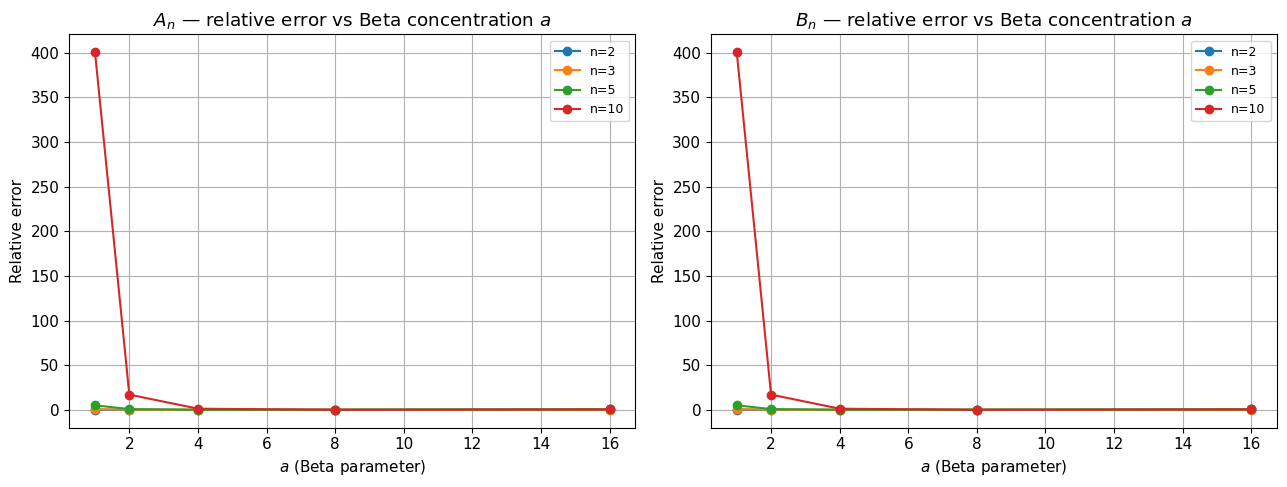

In [ ]:
a_values  = [1, 2, 4, 8, 16]
test_dims = [2, 3, 5, 10]
N_IS      = 8192

rows_a = []
for shape in ["A", "B"]:
    for n in test_dims:
        for a in a_values:
            r = importance_sampling(shape, n=n, N=N_IS, a=a, seed=SEED)
            rows_a.append(r)

df_a = pd.DataFrame(rows_a)

# ── Plot: relative error vs a for each dimension ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, shape in zip(axes, ["A", "B"]):
    sub = df_a[df_a["shape"]==shape]
    for n in test_dims:
        s2 = sub[sub["n"]==n]
        ax.plot(s2["a"], s2["rel_error"], "o-", label=f"n={n}")
    ax.set(title=f"${shape}_n$ — relative error vs Beta concentration $a$",
           xlabel="$a$ (Beta parameter)", ylabel="Relative error")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 6.2 Importance sampling across dimensions (best $a$ fixed at 4)

In [ ]:
IS_DIMS = [2, 3, 5, 10, 20]
BEST_A  = 4    # good balance from sweep above
N_IS    = 8192

rows_is = [importance_sampling(s, n, N=N_IS, a=BEST_A)
           for s in ["A","B"] for n in IS_DIMS]
df_is = pd.DataFrame(rows_is)

df_is[["shape","n","N","hits","estimate","exact","abs_error","rel_error"]].round(6)

,shape,n,N,hits,estimate,exact,abs_error,rel_error
0,A,2,8192,8179,0.748552,0.785398,0.036846,0.046914
1,A,3,8192,8097,0.525241,0.523599,0.001642,0.003136
2,A,5,8192,7498,0.180599,0.164493,0.016106,0.097910
3,A,10,8192,3503,0.005716,0.002490,0.003226,1.295400
4,A,20,8192,69,0.000003,0.000000,0.000003,112.458414
5,B,2,8192,8179,2.994208,3.141593,0.147384,0.046914
6,B,3,8192,8097,4.201927,4.188790,0.013137,0.003136
7,B,5,8192,7498,5.779169,5.263789,0.515380,0.097910
8,B,10,8192,3503,5.853648,2.550164,3.303483,1.295400
9,B,20,8192,69,2.928009,0.025807,2.902202,112.458414


---
## Full Method Comparison

All seven methods side-by-side across dimensions 2 to 20. Recursive slicing is included as the deterministic numerical improvement against the stochastic methods.


In [ ]:
CMP_DIMS = [2, 3, 5, 10, 20]
N_CMP    = 8192
QMC_M    = int(math.log2(N_CMP))   # 2^13 = 8192 Sobol points

cmp_rows = []
for shape in ["A", "B"]:
    for n in CMP_DIMS:
        lv_exact = log_vol_A(n) if shape=="A" else log_vol_B(n)
        exact    = math.exp(lv_exact) if lv_exact > -745 else 0.0

        mc_r  = monte_carlo(shape, n, N=N_CMP)
        rep_r = repeated_mc(shape, n, N=N_CMP, repeats=20)
        qmc_r = quasi_mc(shape, n, m=QMC_M)
        is_r  = importance_sampling(shape, n, N=N_CMP, a=BEST_A)
        slicing_log = (recursive_slicing_log_volume_A(n)[0]
                       if shape == "A" else recursive_slicing_log_volume_B(n)[0])

        cmp_rows.append(dict(
            shape=shape, n=n, exact=exact,
            crude_MC        = mc_r["estimate"],
            repeated_MC_mean= rep_r["mean"],
            log_vol_exact   = lv_exact,          # exact log-volume formula
            recursive_slicing=safe_exp(slicing_log),
            sobol_QMC       = qmc_r["estimate"],
            importance_samp = is_r["estimate"],
            # Direct radial does not produce a volume estimate (see note)
        ))

df_cmp = pd.DataFrame(cmp_rows)
df_cmp.round(6)


,shape,n,exact,crude_MC,repeated_MC_mean,log_vol_exact,recursive_slicing,sobol_QMC,importance_samp
0,A,2,0.785398,0.781982,0.784845,-0.241564,0.785398,0.785522,0.748552
1,A,3,0.523599,0.518066,0.522626,-0.647030,0.523599,0.524902,0.525241
2,A,5,0.164493,0.165283,0.165466,-1.804885,0.164493,0.162354,0.180599
3,A,10,0.002490,0.002319,0.002380,-5.995314,0.002490,0.002075,0.005716
4,A,20,0.000000,0.000000,0.000000,-17.520057,0.000000,0.000000,0.000003
5,B,2,3.141593,3.127930,3.139380,1.144730,3.141593,3.142090,2.994208
6,B,3,4.188790,4.144531,4.181006,1.432412,4.188790,4.199219,4.201927
7,B,5,5.263789,5.289062,5.294922,1.660851,5.263789,5.195312,5.779169
8,B,10,2.550164,2.375000,2.437500,0.936158,2.550164,2.125000,5.853648
9,B,20,0.025807,0.000000,0.000000,-3.657114,0.025807,0.000000,2.928009


shape  n   method    N     ESS  efficiency
    A  2 Crude MC 4096 4096.00      1.0000
    A  2   IS a=2 4096 2736.17      0.6680
    A  2   IS a=4 4096  416.35      0.1016
    A  2   IS a=8 4096   17.60      0.0043
    A  3 Crude MC 4096 4096.00      1.0000
    A  3   IS a=2 4096 2669.43      0.6517
    A  3   IS a=4 4096  636.08      0.1553
    A  3   IS a=8 4096   48.53      0.0118
    A  5 Crude MC 4096 4096.00      1.0000
    A  5   IS a=2 4096 1966.29      0.4801
    A  5   IS a=4 4096 1140.24      0.2784
    A  5   IS a=8 4096  151.61      0.0370
    A 10 Crude MC 4096 4096.00      1.0000
    A 10   IS a=2 4096  223.31      0.0545
    A 10   IS a=4 4096 1304.07      0.3184
    A 10   IS a=8 4096  718.60      0.1754
    A 20 Crude MC 4096 4096.00      1.0000
    A 20   IS a=2 4096    0.00      0.0000
    A 20   IS a=4 4096   33.92      0.0083
    A 20   IS a=8 4096  802.66      0.1960
    B  2 Crude MC 4096 4096.00      1.0000
    B  2   IS a=2 4096 2736.17      0.6680
    B  2   

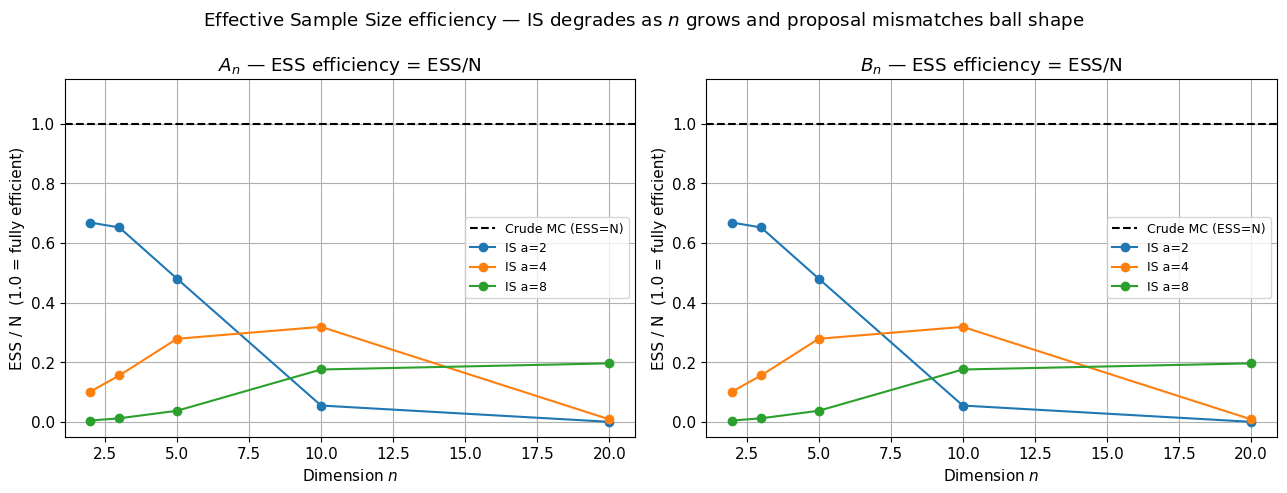

In [ ]:
# ── Effective Sample Size (ESS) across methods and dimensions ─────────────────
# Placement: Notebook 2, after df_cmp full comparison block

def ess_importance(shape, n, N=4096, a=4.0, seed=SEED):
    """
    Compute ESS for importance sampling via the weight-variance formula:
        ESS = (sum w_i)^2 / sum(w_i^2)
    Returns ESS and ESS/N (efficiency ratio).
    """
    from scipy.special import betaln as _betaln
    rng = np.random.default_rng(seed)
    u   = rng.beta(a, a, size=(N, n))
    log_beta = _betaln(a, a)
    log_q_u  = ((a-1) * (np.log(u) + np.log1p(-u)) - log_beta).sum(axis=1)

    if shape == "A":
        inside = in_A(u);          log_q_x = log_q_u
    else:
        inside = in_B(2*u - 1);   log_q_x = log_q_u - n*math.log(2)

    # unnormalised weights w_i = 1[inside] / q(x_i)
    log_w = np.where(inside, -log_q_x, -math.inf)
    # clip for numerical safety
    log_w_finite = log_w[np.isfinite(log_w)]
    if len(log_w_finite) == 0:
        return dict(shape=shape, n=n, a=a, N=N, ESS=0.0, efficiency=0.0)
    shift = log_w_finite.max()
    w = np.exp(log_w - shift)          # shift cancels in ratio
    ESS = w.sum()**2 / (w**2).sum()
    return dict(shape=shape, n=n, a=a, N=N,
                ESS=round(ESS, 2), efficiency=round(ESS/N, 4))


def ess_crude_mc(shape, n, N=4096, seed=SEED):
    """ESS for crude MC = N always (i.i.d. uniform samples)."""
    return dict(shape=shape, n=n, method="Crude MC", N=N, ESS=float(N), efficiency=1.0)


ESS_DIMS = [2, 3, 5, 10, 20]
N_ESS    = 4096
a_vals   = [2, 4, 8]

# ESS for importance sampling across a values and dimensions
ess_rows = []
for shape in ["A", "B"]:
    for n in ESS_DIMS:
        ess_rows.append({**ess_crude_mc(shape, n, N=N_ESS), "a": None})
        for a in a_vals:
            r = ess_importance(shape, n, N=N_ESS, a=a)
            ess_rows.append({**r, "method": f"IS a={a}"})

df_ess = pd.DataFrame(ess_rows)
print(df_ess[["shape","n","method","N","ESS","efficiency"]].to_string(index=False))

# ── Plot ESS efficiency by dimension ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, shape in zip(axes, ["A","B"]):
    sub = df_ess[df_ess["shape"]==shape]
    # crude MC (flat at 1.0)
    ax.axhline(1.0, color="k", ls="--", lw=1.5, label="Crude MC (ESS=N)")
    for a in a_vals:
        s = sub[sub["method"]==f"IS a={a}"]
        ax.plot(s["n"], s["efficiency"], "o-", label=f"IS a={a}")
    ax.set(title=f"${shape}_n$ — ESS efficiency = ESS/N",
           xlabel="Dimension $n$", ylabel="ESS / N  (1.0 = fully efficient)",
           ylim=(-0.05, 1.15))
    ax.legend(fontsize=9)

plt.suptitle("Effective Sample Size efficiency — IS degrades as $n$ grows and proposal mismatches ball shape")
plt.tight_layout()
plt.show()

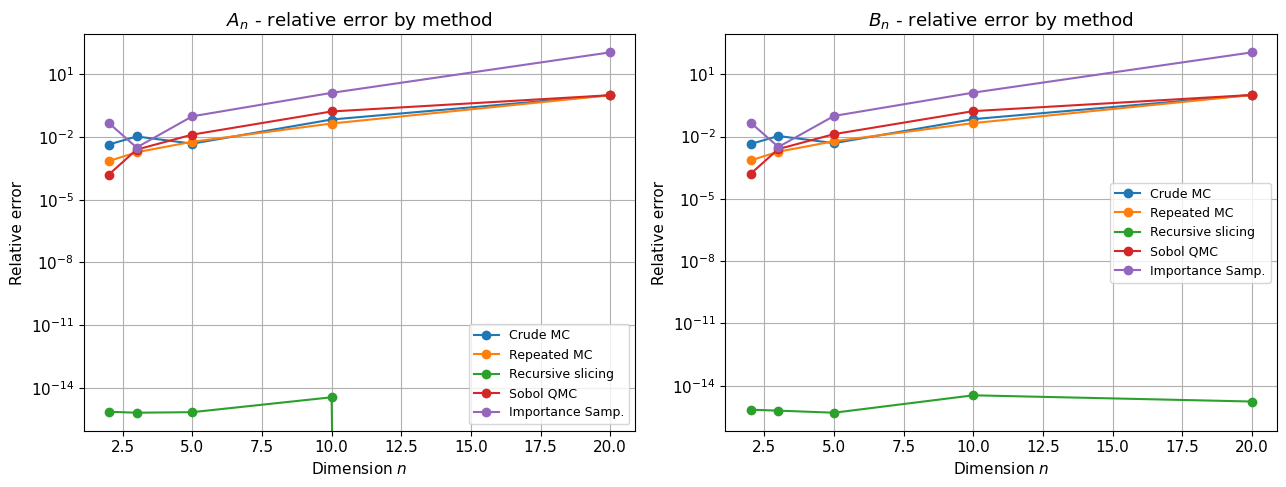

In [ ]:
# Relative errors for each sampling/numerical method
methods = {
    "Crude MC":         "crude_MC",
    "Repeated MC":      "repeated_MC_mean",
    "Recursive slicing": "recursive_slicing",
    "Sobol QMC":        "sobol_QMC",
    "Importance Samp.": "importance_samp",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, shape in zip(axes, ["A","B"]):
    sub = df_cmp[df_cmp["shape"]==shape]
    for label, col in methods.items():
        re = (sub[col] - sub["exact"]).abs() / sub["exact"]
        ax.plot(sub["n"], re, "o-", label=label)
    ax.set(title=f"${shape}_n$ - relative error by method",
           xlabel="Dimension $n$", ylabel="Relative error",
           yscale="log")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


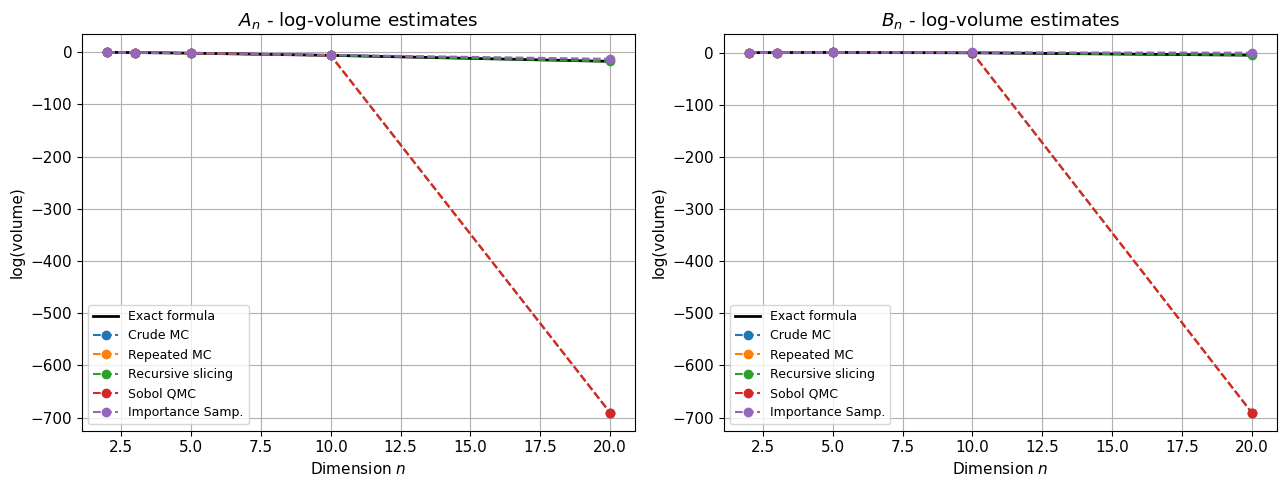

In [ ]:
# Log-volume view - all methods vs exact
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, shape in zip(axes, ["A","B"]):
    sub = df_cmp[df_cmp["shape"]==shape]
    ns  = sub["n"].values

    ax.plot(ns, sub["log_vol_exact"], "k-",  lw=2,  label="Exact formula")
    for label, col in methods.items():
        vals = sub[col].clip(lower=1e-300)
        ax.plot(ns, np.log(vals), "o--", label=label)

    ax.set(title=f"${shape}_n$ - log-volume estimates",
           xlabel="Dimension $n$", ylabel="log(volume)")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
# ── Hit count comparison — how many samples are actually useful? ───────────────
hit_rows = []
for shape in ["A","B"]:
    for n in CMP_DIMS:
        mc_h  = monte_carlo(shape, n, N=N_CMP)["hits"]
        qmc_h = quasi_mc(shape, n, m=QMC_M)["hits"]
        is_h  = importance_sampling(shape, n, N=N_CMP, a=BEST_A)["hits"]
        rad_h = N_CMP   # direct radial: every sample is inside by construction
        hit_rows.append(dict(shape=shape, n=n,
                             crude_MC=mc_h, sobol_QMC=qmc_h,
                             importance=is_h, direct_radial=rad_h))

df_hits = pd.DataFrame(hit_rows)
print("Hits per N =", N_CMP, "samples:")
df_hits

Hits per N = 8192 samples:


,shape,n,crude_MC,sobol_QMC,importance,direct_radial
0,A,2,6406,6435,8179,8192
1,A,3,4244,4300,8097,8192
2,A,5,1354,1330,7498,8192
3,A,10,19,17,3503,8192
4,A,20,0,0,69,8192
5,B,2,6406,6435,8179,8192
6,B,3,4244,4300,8097,8192
7,B,5,1354,1330,7498,8192
8,B,10,19,17,3503,8192
9,B,20,0,0,69,8192


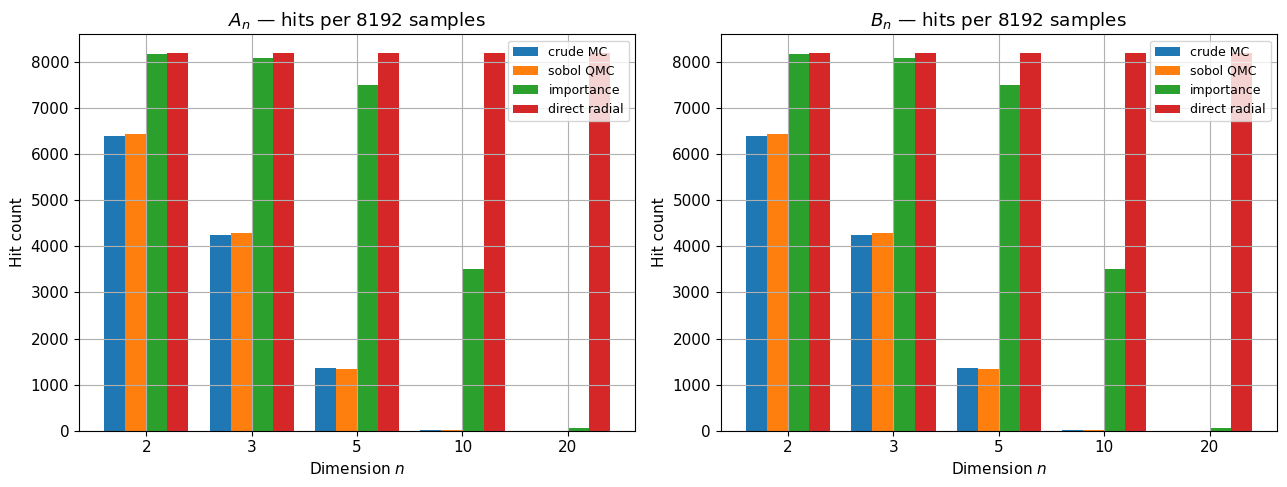

In [ ]:
# ── Bar chart: hit count by method and dimension ───────────────────────────────
hit_cols = ["crude_MC", "sobol_QMC", "importance", "direct_radial"]
x = np.arange(len(CMP_DIMS))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, shape in zip(axes, ["A","B"]):
    sub = df_hits[df_hits["shape"]==shape].reset_index(drop=True)
    for i, col in enumerate(hit_cols):
        ax.bar(x + i*width, sub[col], width, label=col.replace("_"," "))
    ax.set(title=f"${shape}_n$ — hits per {N_CMP} samples",
           xlabel="Dimension $n$", ylabel="Hit count",
           xticks=x+width*1.5, xticklabels=CMP_DIMS)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Summary Table - All Seven Methods

| Method | Estimates volume? | Works in high-$n$? | Key strength | Key limitation |
|--------|:-----------------:|:------------------:|--------------|----------------|
| Bounding-box MC | Yes | No | Simple baseline | Hit rate goes to 0 exponentially |
| Repeated MC | Yes | No | Quantifies variance and CI | Same fundamental zero-hit failure |
| Log-volume exact | Yes | Yes | Exact, no underflow | Analytic formula required |
| Recursive slicing | Yes | Yes | Stable cross-sectional integration | Slower than the closed-form Gamma benchmark |
| Sobol QMC | Yes | Limited | Lower error at moderate dimensions | Still fails when hit rate goes to 0 |
| Direct radial | No* | Yes | Zero wasted samples; reveals geometry | Cannot estimate volume alone |
| Importance sampling | Yes | Limited | More hits via centred proposal | Degrades if proposal misses the ball shape |

*Direct radial sampling generates points inside the ball by construction. It cannot measure the fraction of the bounding box occupied by the ball, so no volume estimate is produced.

> **Practical recommendation:** For exact results at any $n$, use the log-volume formula. Recursive slicing is the main numerical improvement here: it matches the Gamma benchmark closely while avoiding the zero-hit failure of bounding-box Monte Carlo.
> For Monte Carlo, importance sampling with a well-tuned proposal outperforms crude MC at low-to-moderate dimensions, but all hit-counting sampling methods eventually fail once the hit probability drops below $1/N$.
